In [1]:
# %matplotlib widget
import sys
import os
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.ephys_functions import*
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import spikeinterface as si
from trimesh import load_mesh
import k3d
import matplotlib.cm as cm
from matplotlib.colors import Normalize

%matplotlib inline


In [7]:
unit_tbl = get_unit_tbl('behavior_841596_2026-03-24_13-06-50','raw',summary=True)
unit_tbl.head()

,unit_id,bl_max_p,p_max,p_mean,lat_max_p,lat_mean,euc_max_p,corr_max_p,opto_pass,amp,...,waveform_mean,waveform_sd,default_qc,peak_wf,peak_wf_aligned,wf_2d,DRN_range_top,DRN_range_bottom,tagged_loc,tagged
0,42,0.070851,0.929149,0.453983,0.007429,0.007226,NaN,NaN,True,82.613695,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",True,"[12.09780502319336, 12.875853538513184, 12.788...","[12.09780502319336, 12.875853538513184, 12.788...","[[-0.9594002962112427, -0.8423998355865479, -0...",None,None,False,False
1,43,0.116928,0.883072,0.421403,0.007582,0.009264,NaN,NaN,True,143.383484,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",True,"[6.429149150848389, 5.890952110290527, 6.04304...","[6.429149150848389, 5.890952110290527, 6.04304...","[[-0.6610502004623413, -0.9769498705863953, -1...",None,None,False,False
2,44,0.065037,0.734963,0.341962,0.009532,0.009339,NaN,NaN,True,56.101513,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",True,"[5.504850387573242, 5.79149866104126, 5.756402...","[5.504850387573242, 5.79149866104126, 5.756402...","[[0.8599498271942139, 1.1465998888015747, 1.19...",None,None,False,False
3,53,0.132808,0.717192,0.312267,0.015418,0.012684,NaN,NaN,True,70.580275,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",True,"[4.4050493240356445, 3.901949644088745, 3.7381...","[4.4050493240356445, 3.901949644088745, 3.7381...","[[3.012749195098877, 2.3399999141693115, 1.287...",None,None,False,False


In [2]:
def make_ccf_tbl(animal_id, annotator = 'zs', data_type = 'curated', save_to_session = True, plot_3D = True):
    annotation_dir = f'/root/capsule/data/alignment_{annotator}/{animal_id}'
    if os.path.exists(annotation_dir) == False:
        print('No annotation directory found')
    dorsal_edge_json = f'/root/capsule/data/dorsal_edges/{animal_id}_dorsal_edge_ccf_fix.json'
    if os.path.exists(dorsal_edge_json):
        with open(dorsal_edge_json, 'r') as f:
            dorsal_edge_dict = json.load(f)
        # make into a dataframe
        dorsal_edge_df = pd.DataFrame(dorsal_edge_dict['xyz_picks'], columns=['x', 'y', 'z'])
        dorsal_edge_mat = dorsal_edge_df.values
        # dorsal_edge_mat[:, 0] = dorsal_edge_mat[:, 0] - 0.04
        # make into a dataframe
        # dorsal_edge_df['x'] = -dorsal_edge_df['x']/1000
        # dorsal_edge_df['y'] = -dorsal_edge_df['y']/1000
        # dorsal_edge_df['z'] = dorsal_edge_df['z']/1000

    # grab all session ids for this animal
    session_list_annotation = os.listdir(annotation_dir)
    date_list_annotation = [parseSessionID(session)[1] for session in session_list_annotation]
    session_assets = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')
    session_list_all = session_assets['session_id']
    session_list_animal = [session for session in session_list_all if isinstance(session, str)]
    session_list_animal = [session for session in session_list_animal if animal_id in session]
    date_list_animal = [parseSessionID(session)[1] for session in session_list_animal]

    # for each date_list, find the corresponding session in session_list_all within 1 minute tolerance
    session_list = []
    for date in date_list_annotation:
        time_diff = [abs((date_list_animal_curr - date).total_seconds()) for date_list_animal_curr in date_list_animal]
        min_ind = np.argmin(time_diff)
        if time_diff[min_ind] < 60:
            session_list.append(session_list_animal[min_ind])
        else:
            session_list.append(None)
    
    unit_tbls = []
    probe_tbls = []
    for session_ind in range(len(session_list)):
        if session_list[session_ind] is None:
            print(f'No matching session found for {session_list_annotation[session_ind]}')
            unit_tbls.append(None)
            probe_tbls.append(None)    
        else:      
            print(f'Processing {session_list_annotation[session_ind]} matched to {session_list[session_ind]}')
            session = session_list[session_ind]
            session_annotation = session_list_annotation[session_ind]
            session_dir = session_dirs(session_id=session)
            if session_dir[f'postprocessed_dir_{data_type}'] is None:
                print(f'{data_type} data does not exist')
                unit_tbls.append(None)
                probe_tbls.append(None)
            else:    
                sorting_analyzer = si.load(session_dir[f'postprocessed_dir_{data_type}'], load_extensions=False)
                channel_locations = sorting_analyzer.get_channel_locations()
                unit_locations = sorting_analyzer.get_extension("unit_locations").get_data()
                channel_ids = sorting_analyzer.channel_ids
                channel_num = [int(chan[2:]) for chan in channel_ids]
                unit_loc_along_probe = unit_locations[:, 1]
                channel_loc_along_probe = channel_locations[:, 1]
                ccf_location_file = os.path.join(annotation_dir, session_annotation, 'ProbeA/ccf_channel_locations.json')
                ccf_dict = json.load(open(ccf_location_file, 'r'))
                ccf_df = pd.DataFrame(ccf_dict).T
                ccf_df.index = ccf_df.index.astype(str)  # make sure index is string
                ccf_df["channel_ind"] = ccf_df.index.str.split("_").str[1].astype(int)
                # filter by if channel_ind in channel_num
                ccf_df = ccf_df[ccf_df["channel_ind"].isin(channel_num)]
                ccf_df["loc_along_probe"] = channel_loc_along_probe
                # x for ml, y for ap, z for dv, with ccf origin and scale of mm
                xp = pd.to_numeric(ccf_df['loc_along_probe'], errors='raise').to_numpy()
                fp_x = pd.to_numeric(ccf_df['x'], errors='raise').to_numpy()
                fp_y = pd.to_numeric(ccf_df['y'], errors='raise').to_numpy()
                fp_z = pd.to_numeric(ccf_df['z'], errors='raise').to_numpy()

                unit_x_ccf = np.interp(unit_loc_along_probe, xp, fp_x)
                unit_y_ccf = np.interp(unit_loc_along_probe, xp, fp_y)
                unit_z_ccf = np.interp(unit_loc_along_probe, xp, fp_z)
                unit_ccf_df = pd.DataFrame({'unit_id': sorting_analyzer.unit_ids,
                                        'x_ccf': unit_x_ccf,
                                        'y_ccf': unit_y_ccf,
                                        'z_ccf': unit_z_ccf,
                                        'loc_along_probe': unit_loc_along_probe})
                unit_tbl = get_unit_tbl(session, data_type)
                unit_tbl = unit_tbl.drop(columns=['x_ccf', 'y_ccf', 'z_ccf'], errors="ignore")
                if save_to_session:
                    save_dir = os.path.join(session_dir[f'ephys_processed_dir_{data_type}'],'ccf_unit_locations.csv')
                    unit_ccf_df.to_csv(save_dir, index=False)
                unit_tbl_combined = unit_tbl.merge(unit_ccf_df, left_on='unit_id', right_on='unit_id', how='left')
                corr = unit_tbl_combined['corr_max_p'].values
                corr[np.isnan(corr)] = 1
                unit_tbl_combined = unit_tbl_combined[(unit_tbl_combined['decoder_label']!='artifact') & (corr>=0.80) & (unit_tbl_combined['lat_mean']>=0.004)]
                probe_tbls.append(ccf_df)
                unit_tbls.append(unit_tbl_combined)


    norm = Normalize(vmin=0, vmax=1)
    ml, ap, dv = 0, 1, 2
    planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}


    mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
    mesh = load_mesh(mesh_file)
    bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
    mesh_vertices = np.array(mesh.vertices)
    mesh_vertices = mesh_vertices/1000
    if 'scratch' in mesh_file:
        mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
        mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
        mesh_vertices_mm = mesh_vertices_lps
    else:
        mesh_vertices_mm = mesh_vertices.copy()
        mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
        mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
        # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
        mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
    mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

    mesh_contours = {
        plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
        for plane_name, plane_axes in planes.items()
    }
    # add the other side
    mesh_vertices_mm_flipped = mesh_vertices_mm.copy()
    mesh_vertices_mm_flipped[:, ml] = -mesh_vertices_mm_flipped[:, ml]
    mesh_vertices_mm_bi = np.vstack([mesh_vertices_mm, mesh_vertices_mm_flipped])
    colormaps = ['Reds', 'Greens', 'Blues', 'Oranges', 'Greys']

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    import matplotlib.cm as cm
    import matplotlib.patches as mpatches
    for plane, ax in zip(planes.keys(), axes):
        # Plot the mesh
        ax.scatter(
            mesh_vertices_mm_bi[:, planes[plane][0]],
            mesh_vertices_mm_bi[:, planes[plane][1]],
            color='gray', alpha=0.5, s=0.005,
            edgecolors=None
        )

        # plot dorsal edge if exists
        if os.path.exists(dorsal_edge_json):
            ax.scatter(
                dorsal_edge_mat[:, planes[plane][0]],
                dorsal_edge_mat[:, planes[plane][1]],
                color='b', s=1,
                edgecolors=None
            )

        # Plot the points
        for session_ind, session in enumerate(session_list):
            unit_tbl_combined = unit_tbls[session_ind]
            if unit_tbl_combined is None:
                continue
            unit_tbl_combined = unit_tbl_combined.sort_values(by="p_max", ascending=True)
            ccfs = unit_tbl_combined[['x_ccf', 'y_ccf', 'z_ccf']].values
            bregma_LPS_mm = np.array([-5.70, 5.4, -0.45])  # in mm
            ccfs = ccfs - bregma_LPS_mm

            # for probe
            ccfs_probe = probe_tbls[session_ind][['x', 'y', 'z']].values
            ccfs_probe = ccfs_probe - bregma_LPS_mm
            sc = ax.scatter(
                ccfs_probe[:, planes[plane][0]], 
                ccfs_probe[:, planes[plane][1]], 
                color='k', 
                s=5, 
                edgecolors=None,
                linewidth=0.2
                )

            sc = ax.scatter(
                ccfs[:, planes[plane][0]],
                ccfs[:, planes[plane][1]],
                c=unit_tbl_combined['p_max'],
                cmap=colormaps[session_ind],
                norm=Normalize(vmin=0, vmax=0.6),   # ← normalize color scale
                s=50, alpha=0.3,
                edgecolors=None, linewidths=1,
            )

            sort_ind = np.argsort(ccfs[:, dv])
            
            # ax.plot(ccfs[sort_ind, planes[plane][0]], ccfs[sort_ind, planes[plane][1]], color=cm.get_cmap(colormaps[session_ind])(1.0), label=session, linewidth=0.5)

        ax.set_xlabel(planes[plane][0])
        ax.set_ylabel(planes[plane][1])
        ax.set_aspect('equal')

    # add the legend with brightest color for each session

    legend_handles = []
    for session_ind, session in enumerate(session_list):
        cmap = cm.get_cmap(colormaps[session_ind])
        brightest = cmap(1.0)  # lowest value = brightest in Reds/Greens/Blues
        patch = mpatches.Patch(color=brightest, label=session)
        legend_handles.append(patch)

    axes[1].legend(handles=legend_handles, title="Sessions")


    # axes[0].invert_yaxis()
    axes[0].invert_xaxis()
    # axes[2].invert_yaxis()


    plt.suptitle(f'{animal_id} units in CCF space with max(P(spike|laser)) color coding')
    plt.tight_layout()
    os.makedirs(f'/root/capsule/scratch/combined/ccf_maps/{annotator}', exist_ok=True)
    plt.savefig(f'/root/capsule/scratch/combined/ccf_maps/{annotator}/{animal_id}_{annotator}_units_ccf_opto_tag.png', dpi=300)


    colormaps = ['Reds', 'Greens', 'Blues', 'Oranges', 'Greys']

    # --- Load and preprocess mesh ---

    if plot_3D:
        # Convert mesh to k3d mesh
        vertices = mesh_vertices_bi.astype(np.float32)
        indices = np.array(mesh.faces, dtype=np.uint32)

        plot = k3d.plot(camera_auto_fit=True)

        plt_mesh = k3d.mesh(
            vertices=vertices,
            indices=indices,
            color=0x888888,   # gray mesh
            opacity=0.1,
            wireframe=False,
            name='LC_right'
        )

        vertices_flipped = vertices.copy()
        vertices_flipped[:, ml] = -vertices_flipped[:, ml]

        plt_mesh_flipped = k3d.mesh(
            vertices=vertices_flipped,
            indices=indices,
            color=0x888888,   # gray mesh
            opacity=0.1,
            wireframe=False,
            name='LC_left'
        )

        plot += plt_mesh
        plot += plt_mesh_flipped

        # add dorsal edge if exists
        if os.path.exists(dorsal_edge_json):
            plt_dorsal = k3d.points(
                positions=dorsal_edge_mat.astype(np.float32),
                point_size=0.02,
                color=0x0000FF,   # blue points
                shader="3d",
                name='Dorsal_edge'
            )
            plot += plt_dorsal

        # --- Add probes + units for each session ---
        for session_ind, session in enumerate(session_list):
            if unit_tbls[session_ind] is None:
                continue

            unit_tbl_combined = unit_tbls[session_ind].sort_values(by="p_max", ascending=True)

            # Units
            ccfs = unit_tbl_combined[['x_ccf', 'y_ccf', 'z_ccf']].values
            ccfs = ccfs - bregma_LPS_mm

            # Probes
            ccfs_probe = probe_tbls[session_ind][['x', 'y', 'z']].values
            ccfs_probe = ccfs_probe - bregma_LPS_mm

            # Colormap based on p_max


            # Colormap based on p_max, normalized to 0–0.6
            norm = Normalize(vmin=0, vmax=0.6)
            cmap = cm.get_cmap(colormaps[session_ind])
            pmax_normalized = norm(unit_tbl_combined['p_max'].values)

            # Convert to RGB (0–255) and then to integer color codes
            colors_rgb = (cmap(pmax_normalized)[:, :3] * 255).astype(np.uint32)
            colors = (colors_rgb[:, 0] << 16) + (colors_rgb[:, 1] << 8) + colors_rgb[:, 2]

            # Units
            plt_units = k3d.points(
                positions=ccfs.astype(np.float32),
                point_size=0.05,
                colors=colors,
                opacity=0.4,
                shader="3d",
                name=f'Units_{session[9:]}'
            )
            plot += plt_units


            # Probes (black points)
            plt_probes = k3d.points(
                positions=ccfs_probe.astype(np.float32),
                point_size=0.02,
                color=0x000000,
                shader="3d",
                name=f'Probe_{session[9:]}'
            )
            plot += plt_probes
        # save a html file
        # --- Save interactive plot to HTML ---
        html_file = f'/root/capsule/scratch/combined/ccf_maps/{animal_id}_{annotator}_units_ccf_plot.html'
        with open(html_file, 'w') as f:
            f.write(plot.get_snapshot())

        plot.display()

In [2]:
# assumes parseSessionID, session_dirs, get_unit_tbl, si, load_mesh, pir_to_lps exist
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.lines import Line2D

def _collect_ccf_for_annotator(
    animal_id: str,
    annotator: str = "fix",
    data_type: str = "raw",
    save_to_session: bool = True,
):
    """
    Do the same work as make_ccf_tbl but only up to generating
    per-session unit CCF tables. Returns dicts keyed by session_id.
    """
    annotation_dir = f"/root/capsule/data/alignment_{annotator}/{animal_id}"
    if not os.path.exists(annotation_dir):
        print(f"[{annotator}] No annotation directory found at {annotation_dir}")
        return {}, {}

    # All annotation session folders for this animal
    session_list_annotation = os.listdir(annotation_dir)
    date_list_annotation = [parseSessionID(session)[1] for session in session_list_annotation]

    # All sessions from session_assets, filter to this animal
    session_assets = pd.read_csv("/root/capsule/code/data_management/session_assets.csv")
    session_list_all = session_assets["session_id"]
    session_list_animal = [session for session in session_list_all if isinstance(session, str)]
    session_list_animal = [session for session in session_list_animal if animal_id in session]
    date_list_animal = [parseSessionID(session)[1] for session in session_list_animal]

    # Match annotation sessions to IBL sessions within 1 minute
    matched_sessions = []
    for date in date_list_annotation:
        time_diff = [abs((date_animal - date).total_seconds()) for date_animal in date_list_animal]
        min_ind = np.argmin(time_diff)
        if time_diff[min_ind] < 60:
            matched_sessions.append(session_list_animal[min_ind])
        else:
            matched_sessions.append(None)

    # Per-session dicts (keyed by IBL session_id)
    session_unit_tbls = {}
    session_probe_tbls = {}

    for idx, session in enumerate(matched_sessions):
        annot_session = session_list_annotation[idx]

        if session is None:
            print(f"[{annotator}] No matching session found for {annot_session}")
            continue

        print(f"[{annotator}] Processing {annot_session} → {session}")
        session_dir = session_dirs(session_id=session)

        if session_dir.get(f"postprocessed_dir_{data_type}") is None:
            print(f"[{annotator}] {data_type} data does not exist for {session}")
            continue

        # Load sorting analyzer and locations
        sorting_analyzer = si.load(session_dir[f"postprocessed_dir_{data_type}"], load_extensions=False)
        channel_locations = sorting_analyzer.get_channel_locations()
        unit_locations = sorting_analyzer.get_extension("unit_locations").get_data()
        channel_ids = sorting_analyzer.channel_ids
        channel_num = [int(chan[2:]) for chan in channel_ids]
        unit_loc_along_probe = unit_locations[:, 1]
        channel_loc_along_probe = channel_locations[:, 1]

        # Load annotator's CCF channel locations
        ccf_location_file = os.path.join(
            annotation_dir,
            annot_session,
            "ProbeA/ccf_channel_locations.json",
        )
        if not os.path.exists(ccf_location_file):
            print(f"[{annotator}] Missing CCF file: {ccf_location_file}")
            continue

        with open(ccf_location_file, "r") as f:
            ccf_dict = json.load(f)
        ccf_df = pd.DataFrame(ccf_dict).T
        ccf_df.index = ccf_df.index.astype(str)
        ccf_df["channel_ind"] = ccf_df.index.str.split("_").str[1].astype(int)

        # Keep only channels that exist in this recording
        ccf_df = ccf_df[ccf_df["channel_ind"].isin(channel_num)]
        ccf_df["loc_along_probe"] = channel_loc_along_probe

        # prepare interpolation
        xp = pd.to_numeric(ccf_df["loc_along_probe"], errors="raise").to_numpy()
        fp_x = pd.to_numeric(ccf_df["x"], errors="raise").to_numpy()
        fp_y = pd.to_numeric(ccf_df["y"], errors="raise").to_numpy()
        fp_z = pd.to_numeric(ccf_df["z"], errors="raise").to_numpy()

        unit_x_ccf = np.interp(unit_loc_along_probe, xp, fp_x)
        unit_y_ccf = np.interp(unit_loc_along_probe, xp, fp_y)
        unit_z_ccf = np.interp(unit_loc_along_probe, xp, fp_z)

        unit_ccf_df = pd.DataFrame(
    {
        "unit_id": sorting_analyzer.unit_ids,
        "x_ccf": unit_x_ccf,
        "y_ccf": unit_y_ccf,
        "z_ccf": unit_z_ccf,
        "loc_along_probe": unit_loc_along_probe,
    }
)

        # Save raw CCF coordinates immediately.
        # This is the only thing needed for the master table.
        if save_to_session:
            save_path = os.path.join(
                session_dir[f"ephys_processed_dir_{data_type}"],
                f"ccf_unit_locations_{annotator}.csv",
            )
            unit_ccf_df.to_csv(save_path, index=False)
            print(f"[{annotator}] Saved raw CCF coordinates: {save_path}")

            # Optional: if this annotator/version is your chosen final alignment,
            # also save the canonical filename used by older downstream code.
            if annotator in ["fix", "final"]:
                canonical_path = os.path.join(
                    session_dir[f"ephys_processed_dir_{data_type}"],
                    "ccf_unit_locations.csv",
                )
                unit_ccf_df.to_csv(canonical_path, index=False)
                print(f"[{annotator}] Saved canonical CCF coordinates: {canonical_path}")


        # Store probe table regardless of whether opto/unit table filtering works.
        session_probe_tbls[session] = ccf_df


        # Optional returned unit table.
        # Use summary=False to avoid stale summary pkl files.
        unit_tbl = get_unit_tbl(session, data_type, summary=True)

        if unit_tbl is None:
            print(f"[{annotator}] No unit table for {session}; saved CCF CSV only.")
            continue

        unit_tbl = unit_tbl.copy()
        unit_tbl = unit_tbl.drop(
            columns=["x_ccf", "y_ccf", "z_ccf", "loc_along_probe"],
            errors="ignore",
        )

        unit_tbl_combined = unit_tbl.merge(
            unit_ccf_df,
            on="unit_id",
            how="left",
        )

        # Only apply the old plotting filter if the necessary columns exist.
        filter_cols = ["decoder_label", "corr_max_p", "lat_mean"]
        missing_filter_cols = [
            col for col in filter_cols
            if col not in unit_tbl_combined.columns
        ]

        if len(missing_filter_cols) > 0:
            print(
                f"[{annotator}] {session}: skipping filtered returned unit table; "
                f"missing columns: {missing_filter_cols}"
            )
        else:
            corr = pd.to_numeric(
                unit_tbl_combined["corr_max_p"],
                errors="coerce",
            ).fillna(1)

            lat_mean = pd.to_numeric(
                unit_tbl_combined["lat_mean"],
                errors="coerce",
            )

            unit_tbl_combined = unit_tbl_combined[
                (unit_tbl_combined["decoder_label"] != "artifact")
                & (corr >= 0.70)
                & (lat_mean >= 0.005)
            ].copy()

        session_unit_tbls[session] = unit_tbl_combined

    return session_unit_tbls, session_probe_tbls

def compare_ccf_annotators(
    animal_id: str,
    annotator_A: str = "zs",
    annotator_B: str = "test",
    data_type: str = "curated",
    savefig: bool = True,
):
    """
    Compare CCF unit locations between two annotators for the same animal.
    For units that exist in both annotators' tables (matched by unit_id & session),
    plot arrows from annotator_A → annotator_B in the 3 CCF planes.
    """

    # --- get CCF tables for each annotator ---
    units_A, probes_A = _collect_ccf_for_annotator(
        animal_id, annotator=annotator_A, data_type=data_type, save_to_session=False
    )
    units_B, probes_B = _collect_ccf_for_annotator(
        animal_id, annotator=annotator_B, data_type=data_type, save_to_session=False
    )

    common_sessions = sorted(set(units_A.keys()) & set(units_B.keys()))
    if not common_sessions:
        print("No common sessions with CCF data for both annotators.")
        return

    print(f"Common sessions: {common_sessions}")

    # --- dorsal edge (same for both annotators) ---
    dorsal_edge_json = f"/root/capsule/data/dorsal_edges/{animal_id}_dorsal_edge_ccf_fix.json"
    dorsal_edge_mat = None
    if os.path.exists(dorsal_edge_json):
        with open(dorsal_edge_json, "r") as f:
            dorsal_edge_dict = json.load(f)
        dorsal_edge_df = pd.DataFrame(dorsal_edge_dict["xyz_picks"], columns=["x", "y", "z"])
        # dorsal_edge_df["x"] = -dorsal_edge_df["x"] / 1000.0
        # dorsal_edge_df["y"] = -dorsal_edge_df["y"] / 1000.0
        # dorsal_edge_df["z"] = dorsal_edge_df["z"] / 1000.0
        dorsal_edge_mat = dorsal_edge_df.values
        # dorsal_edge_mat[:, 0] = dorsal_edge_mat[:, 0] - 0.04  # your original shift

    # --- load CCF mesh ---
    mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
    bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
    mesh = load_mesh(mesh_file)
    mesh_vertices = np.array(mesh.vertices)
    mesh_vertices = mesh_vertices/1000
    if 'scratch' in mesh_file:
        mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
        mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
        mesh_vertices_mm = mesh_vertices_lps
    else:
        mesh_vertices_mm = mesh_vertices.copy()
        mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
        mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
        # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
        mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
    mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

    mesh_contours = {
        plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
        for plane_name, plane_axes in planes.items()
    }

    # add other hemisphere (mirror)
    ml, ap, dv = 0, 1, 2
    mesh_vertices_flipped = mesh_vertices_mm.copy()
    mesh_vertices_flipped[:, ml] = -mesh_vertices_flipped[:, ml]
    mesh_vertices_mm_bi = np.vstack([mesh_vertices_mm, mesh_vertices_flipped])

    planes = {"sag": [ap, dv], "hor": [ml, ap], "cor": [ml, dv]}

    # Bregma offset in LPS mm (same as your original)
    bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # distinct colors per session
    sess_colors = cm.get_cmap("tab10")(np.linspace(0, 1, len(common_sessions)))

    all_displacements = []

    for ax, (plane_name, idx_pair) in zip(axes, planes.items()):
        idx_x, idx_y = idx_pair

        # Mesh background
        ax.scatter(
            mesh_vertices_mm_bi[:, idx_x],
            mesh_vertices_mm_bi[:, idx_y],
            color="gray",
            alpha=0.4,
            s=0.05,
            edgecolors="none",
        )

        # dorsal edge
        if dorsal_edge_mat is not None:
            ax.scatter(
                dorsal_edge_mat[:, idx_x],
                dorsal_edge_mat[:, idx_y],
                color="b",
                s=1,
                edgecolors="none",
            )

        for s_i, session in enumerate(common_sessions):
            dfA = units_A[session]
            dfB = units_B[session]

            # match by unit_id
            pairs = dfA[["unit_id", "x_ccf", "y_ccf", "z_ccf"]].merge(
                dfB[["unit_id", "x_ccf", "y_ccf", "z_ccf"]],
                on="unit_id",
                suffixes=("_A", "_B"),
            )

            if pairs.empty:
                print(f"No overlapping units for session {session}")
                continue

            coordsA = pairs[["x_ccf_A", "y_ccf_A", "z_ccf_A"]].values - bregma_LPS_mm
            coordsB = pairs[["x_ccf_B", "y_ccf_B", "z_ccf_B"]].values - bregma_LPS_mm

            xA = coordsA[:, idx_x]
            yA = coordsA[:, idx_y]
            xB = coordsB[:, idx_x]
            yB = coordsB[:, idx_y]

            dx = xB - xA
            dy = yB - yA

            # store 3D displacement for summary
            disp_3d = np.linalg.norm(coordsB - coordsA, axis=1)
            all_displacements.append(disp_3d)

            color_sess = sess_colors[s_i]

            # start points (annotator A)
            ax.scatter(
                xA,
                yA,
                s=10,
                facecolors="none",
                edgecolors=color_sess,
                linewidths=0.7,
                alpha=0.7,
            )

            # end points (annotator B)
            ax.scatter(
                xB,
                yB,
                s=10,
                c=color_sess,
                alpha=0.7,
                marker="x",
            )

            # arrow A → B
            ax.quiver(
                xA,
                yA,
                dx,
                dy,
                angles="xy",
                scale_units="xy",
                scale=1,
                width=0.002,
                alpha=0.4,
                color=color_sess,
            )

        ax.set_xlabel(idx_x)
        ax.set_ylabel(idx_y)
        ax.set_aspect("equal")
        ax.set_title(f"{plane_name} plane")

    # mimic your original invert
    axes[0].invert_xaxis()

    # Legend for annotators + sessions
    session_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="none",
            markeredgecolor=sess_colors[i],
            label=f"Session {i+1}: {sess}",
        )
        for i, sess in enumerate(common_sessions)
    ]

    annot_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="k",
            markerfacecolor="none",
            label=f"{annotator_A} (start)",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            color="k",
            label=f"{annotator_B} (end)",
        ),
    ]

    axes[1].legend(handles=session_handles + annot_handles, fontsize=8)

    plt.suptitle(
        f"{animal_id}: CCF unit locations\nArrows from {annotator_A} → {annotator_B}",
        fontsize=16,
    )
    plt.tight_layout()

    if savefig:
        os.makedirs(name=f"/root/capsule/scratch/combined/ccf_maps/{annotator_A}_to_{annotator_B}/", exist_ok=True)
        out_png = f"/root/capsule/scratch/combined/ccf_maps/{annotator_A}_to_{annotator_B}/{animal_id}_{annotator_A}_to_{annotator_B}_units_ccf_arrows.png"
        plt.savefig(out_png, dpi=300)
        print(f"Saved comparison figure to: {out_png}")

    # summarize displacement
    if all_displacements:
        all_disp = np.concatenate(all_displacements)
        print(
            f"Displacement stats (A→B) in 3D mm for {animal_id}: "
            f"mean={all_disp.mean():.3f}, median={np.median(all_disp):.3f}, "
            f"max={all_disp.max():.3f}, n={len(all_disp)}"
        )

    return

def compare_ccf_between_annotators_3D(animal_id, annotator_A="zs", annotator_B="jx", data_type="curated"):
    print(f"\n===== Comparing annotators {annotator_A} vs {annotator_B} for {animal_id} =====")

    # Load CCF tables
    A_units, A_probes = _collect_ccf_for_annotator(animal_id, annotator_A, data_type)
    B_units, B_probes = _collect_ccf_for_annotator(animal_id, annotator_B, data_type)

    # Find sessions annotated by BOTH
    common_sessions = sorted(set(A_units.keys()) & set(B_units.keys()))
    if not common_sessions:
        print("No common sessions between annotators!")
        return None

    print("Common sessions:", common_sessions)

    # Load dorsal edge
    dorsal_edge_json = f"/root/capsule/data/dorsal_edges/{animal_id}_dorsal_edge_ccf_fix.json"
    dorsal_edge = None
    if os.path.exists(dorsal_edge_json):
        df = pd.DataFrame(json.load(open(dorsal_edge_json))["xyz_picks"],
                          columns=["x","y","z"])
        # df["x"] = -df["x"]/1000
        # df["y"] = -df["y"]/1000
        # df["z"] = df["z"]/1000
        dorsal_edge = df.values
        # dorsal_edge[:,0] -= 0.04

    # Load CCF mesh
    mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
    mesh = load_mesh(mesh_file)
    bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
    mesh_vertices = np.array(mesh.vertices)
    mesh_vertices = mesh_vertices/1000
    if 'scratch' in mesh_file:
        mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
        mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
        mesh_vertices_mm = mesh_vertices_lps
    else:
        mesh_vertices_mm = mesh_vertices.copy()
        mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
        mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
        # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
        mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
    mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

    mesh_contours = {
        plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
        for plane_name, plane_axes in planes.items()
    }
    V = mesh_vertices_mm

    # mirror
    ml, ap, dv = 0,1,2
    Vflip = V.copy()
    Vflip[:,ml] = -Vflip[:,ml]
    Vall = np.vstack([V, Vflip])

    # Bregma shift
    bregma = np.array([-5.70, 5.4, -0.45])

    # ===============================================
    # 2D COMPARISON PLOT
    # ===============================================
    planes = {"sag":[ap,dv], "hor":[ml,ap], "cor":[ml,dv]}

    cmap_sess = cm.get_cmap('tab10')(np.linspace(0,1,len(common_sessions)))

    all_disp = []

    for (pname, idx) in planes.items():

        # sessions
        for si, session in enumerate(common_sessions):
            U_A = A_units[session]
            U_B = B_units[session]

            merged = U_A.merge(U_B, on="unit_id", suffixes=("_A","_B"))
            if merged.empty:
                continue

            Apts = merged[["x_ccf_A","y_ccf_A","z_ccf_A"]].values - bregma
            Bpts = merged[["x_ccf_B","y_ccf_B","z_ccf_B"]].values - bregma

            # accumulate displacement
            disp3d = np.linalg.norm(Bpts - Apts, axis=1)
            all_disp.append(disp3d)

            col = cmap_sess[si]

    # ===============================================
    # 3D INTERACTIVE PLOT
    # ===============================================
    plot3d = k3d.plot(camera_auto_fit=True)

    # meshes
    faces = np.array(mesh.faces, dtype=np.uint32)

    plot3d += k3d.mesh(vertices=V.astype(np.float32), indices=faces,
                       color=0x999999, opacity=0.1, name='mesh_R')
    plot3d += k3d.mesh(vertices=Vflip.astype(np.float32), indices=faces,
                       color=0x999999, opacity=0.1, name='mesh_L')

    # dorsal edge
    if dorsal_edge is not None:
        plot3d += k3d.points(positions=dorsal_edge.astype(np.float32),
                             point_size=0.02, color=0x0000FF, shader='3d')

    color_A = 0x3366FF
    color_B = 0xFF3333
    color_arrow = 0xAAAAAA

    for session in common_sessions:
        U_A = A_units[session]
        U_B = B_units[session]

        merged = U_A.merge(U_B, on="unit_id", suffixes=("_A","_B"))
        if merged.empty:
            continue

        Apts = (merged[["x_ccf_A","y_ccf_A","z_ccf_A"]].values - bregma).astype(np.float32)
        Bpts = (merged[["x_ccf_B","y_ccf_B","z_ccf_B"]].values - bregma).astype(np.float32)

        # plot points
        plot3d += k3d.points(Apts, point_size=0.05, color=color_A, shader='3d', opacity=0.5)
        plot3d += k3d.points(Bpts, point_size=0.05, color=color_B, shader='3d', opacity=0.5)

        # plot arrows
        for a,b in zip(Apts,Bpts):
            AB = np.vstack([a,b]).astype(np.float32)
            plot3d += k3d.line(AB, color=color_arrow, width=0.002)
    os.makedirs(name=f"/root/capsule/scratch/combined/ccf_maps/{annotator_A}_to_{annotator_B}/", exist_ok=True)
    out3d = f"/root/capsule/scratch/combined/ccf_maps/{annotator_A}_to_{annotator_B}/{animal_id}_{annotator_A}_to_{annotator_B}_3D.html"
    with open(out3d, "w") as f:
        f.write(plot3d.get_snapshot())
    print("Saved 3D comparison:", out3d)

    plot3d.display()

    # ===============================================
    # displacement summary
    # ===============================================
    if all_disp:
        all_disp = np.concatenate(all_disp)
        print(f"Displacement stats (mm): mean={all_disp.mean():.4f}, "
              f"median={np.median(all_disp):.4f}, max={all_disp.max():.4f}, n={len(all_disp)}")
    
    return all_disp



In [ ]:
make_ccf_tbl('782394', annotator='fix', data_type='curated', save_to_session=False, plot_3D = False);

In [3]:
from utils.beh_functions import parseSessionID
import pandas as pd

session_assets = pd.read_csv("/root/capsule/code/data_management/session_assets.csv")
session_list = [
    s for s in session_assets["session_id"].values
    if isinstance(s, str)
]

animal_ids = sorted({
    parseSessionID(s)[0]
    for s in session_list
})

#animal_ids = ['843660','848869','843661','844917','844920']

data_type = "raw"      # or "curated", but match your opto table
annotator = "260817"      # or "zs", "jx", etc.

for animal_id in animal_ids:
    try:
        units, probes = _collect_ccf_for_annotator(
            animal_id=animal_id,
            annotator=annotator,
            data_type=data_type,
            save_to_session=True,
        )
        print(animal_id, "sessions saved:", len(probes))
    except:
        print(animal_id, "failed")

[260817] Processing behavior_808650_2025-09-24_12-38-00 → behavior_808650_2025-09-24_12-38-00
[260817] Saved raw CCF coordinates: /root/capsule/scratch/808650/behavior_808650_2025-09-24_12-38-00/ephys/raw/processed/ccf_unit_locations_260817.csv
[260817] Processing behavior_808650_2025-09-26_11-51-57 → behavior_808650_2025-09-26_11-51-57
[260817] Saved raw CCF coordinates: /root/capsule/scratch/808650/behavior_808650_2025-09-26_11-51-57/ephys/raw/processed/ccf_unit_locations_260817.csv
[260817] Processing behavior_808650_2025-09-25_13-35-32 → behavior_808650_2025-09-25_13-35-32
[260817] Saved raw CCF coordinates: /root/capsule/scratch/808650/behavior_808650_2025-09-25_13-35-32/ephys/raw/processed/ccf_unit_locations_260817.csv
808650 sessions saved: 3
[260817] Processing behavior_808655_2025-09-19_15-00-30 → behavior_808655_2025-09-19_15-00-30
[260817] Saved raw CCF coordinates: /root/capsule/scratch/808655/behavior_808655_2025-09-19_15-00-30/ephys/raw/processed/ccf_unit_locations_260817

In [4]:
# %% MASTER TABLE CREATION
# Builds master_all_units_opto_ccf_{data_type}_{annotator}.csv / .pkl
#
# Important change:
#   corr_max_p and euc_max_p are computed directly from
#   {session}_opto_tagging_metrics.pkl -> opto_tagging_df_metrics
#
#   They are NOT read from get_unit_tbl(session, data_type, summary=True),
#   because that can return stale cached summary files.

import os
import glob
import pickle
import traceback
from pathlib import Path

import numpy as np
import pandas as pd

from utils.beh_functions import session_dirs, parseSessionID


# -----------------------------
# Helpers
# -----------------------------

def normalize_unit_id(x):
    """
    Normalize unit IDs for robust merging across int/string/float representations.
    """
    if pd.isna(x):
        return None

    s = str(x).strip()

    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass

    return s


def to_bool_series(s, default=False):
    """
    Robust conversion of mixed bool/int/string columns to boolean.
    """
    if s is None:
        return pd.Series(dtype=bool)

    s = s.copy()

    if len(s) == 0:
        return s.astype(bool)

    if pd.api.types.is_bool_dtype(s):
        return s.fillna(default).astype(bool)

    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(1 if default else 0).astype(float) != 0

    s_str = s.astype(str).str.strip().str.lower()

    true_vals = {"true", "1", "1.0", "t", "yes", "y"}
    false_vals = {"false", "0", "0.0", "f", "no", "n", "none", "nan", "<na>", ""}

    out = pd.Series(default, index=s.index, dtype=bool)
    out[s_str.isin(true_vals)] = True
    out[s_str.isin(false_vals)] = False

    return out


def first_existing_ccf_path(session_dir, data_type="raw", annotator="fix"):
    """
    Finds the CCF coordinate CSV for a session.

    Priority:
        1. ccf_unit_locations_<annotator>.csv
        2. ccf_unit_locations.csv
        3. any ccf_unit_locations*.csv file
    """
    ephys_processed_dir = session_dir[f"ephys_processed_dir_{data_type}"]

    candidates = []

    if annotator is not None:
        candidates.append(
            os.path.join(
                ephys_processed_dir,
                f"ccf_unit_locations_{annotator}.csv",
            )
        )

    candidates.append(
        os.path.join(
            ephys_processed_dir,
            "ccf_unit_locations.csv",
        )
    )

    candidates.extend(
        sorted(
            glob.glob(
                os.path.join(
                    ephys_processed_dir,
                    "ccf_unit_locations*.csv",
                )
            )
        )
    )

    seen = set()
    candidates = [
        c for c in candidates
        if not (c in seen or seen.add(c))
    ]

    for path in candidates:
        if os.path.exists(path):
            return path

    return None


def summarize_opto_metrics(metrics_df, resp_thresh=0.3, lat_thresh=0.02):
    """
    Summarize opto_tagging_df_metrics to one row per unit.

    Source:
        {session}_opto_tagging_metrics.pkl["opto_tagging_df_metrics"]

    Produces:
        p_max
        p_raw_at_max
        p_mean
        lat_max_p
        lat_mean
        pass_count
        corr_max_p
        euc_max_p

    Definition:
        p_max      = max resp_p_bl
        lat_max_p  = resp_lat at max resp_p_bl
        corr_max_p = correlation at max resp_p_bl condition
        euc_max_p  = euclidean_norm at max resp_p_bl condition

    This intentionally does NOT use get_unit_tbl(summary=True).
    """
    if metrics_df is None or len(metrics_df) == 0:
        return pd.DataFrame()

    m = metrics_df.copy()

    if "unit_id" not in m.columns:
        return pd.DataFrame()

    m["_unit_id_str"] = m["unit_id"].apply(normalize_unit_id)

    numeric_cols = [
        "resp_p",
        "resp_p_bl",
        "resp_lat",
        "mean_p",
        "euclidean_norm",
        "correlation",
    ]

    for col in numeric_cols:
        if col in m.columns:
            m[col] = pd.to_numeric(m[col], errors="coerce")
        else:
            m[col] = np.nan

    required = {"resp_p_bl", "resp_lat"}
    if not required.issubset(m.columns):
        return pd.DataFrame()

    m["metric_pass"] = (
        (m["resp_p_bl"] > resp_thresh)
        & (m["resp_lat"] < lat_thresh)
        & (m["resp_lat"] > 0.003)
    )

    rows = []

    for unit_id_str, g in m.groupby("_unit_id_str", dropna=False):
        g = g.copy()
        g_valid = g.dropna(subset=["resp_p_bl"])

        if len(g_valid) == 0:
            rows.append({
                "_unit_id_str": unit_id_str,
                "p_max": np.nan,
                "p_raw_at_max": np.nan,
                "p_mean": np.nan,
                "lat_max_p": np.nan,
                "lat_mean": np.nan,
                "pass_count": 0,
                "corr_max_p": np.nan,
                "euc_max_p": np.nan,
                "n_metric_rows": len(g),
                "n_corr_rows": int(g["correlation"].notna().sum()),
                "n_euc_rows": int(g["euclidean_norm"].notna().sum()),
                "best_power": np.nan,
                "best_site": np.nan,
                "best_duration": np.nan,
                "best_freq": np.nan,
                "best_stim_time": np.nan,
            })
            continue

        best_idx = g_valid["resp_p_bl"].idxmax()
        best = g_valid.loc[best_idx]
        pass_rows = g[g["metric_pass"]]

        rows.append({
            "_unit_id_str": unit_id_str,

            # Response strength
            "p_max": best.get("resp_p_bl", np.nan),
            "p_raw_at_max": best.get("resp_p", np.nan),
            "p_mean": best.get("mean_p", np.nan),

            # Latency
            "lat_max_p": best.get("resp_lat", np.nan),
            "lat_mean": (
                np.nanmean(pd.to_numeric(pass_rows["resp_lat"], errors="coerce"))
                if len(pass_rows) > 0
                else best.get("resp_lat", np.nan)
            ),

            # Reliability
            "pass_count": int(g["metric_pass"].sum()),

            # Waveform similarity at the p_max condition
            "corr_max_p": best.get("correlation", np.nan),
            "euc_max_p": best.get("euclidean_norm", np.nan),

            # Diagnostics
            "n_metric_rows": int(len(g)),
            "n_corr_rows": int(g["correlation"].notna().sum()),
            "n_euc_rows": int(g["euclidean_norm"].notna().sum()),

            # Best condition metadata
            "best_power": best.get("powers", np.nan),
            "best_site": best.get("sites", np.nan),
            "best_duration": best.get("durations", np.nan),
            "best_freq": best.get("freqs", np.nan),
            "best_stim_time": best.get("stim_times", np.nan),
        })

    return pd.DataFrame(rows)


def load_fresh_opto_table(session, data_type="raw", resp_thresh=0.3, lat_thresh=0.02):
    """
    Load fresh optotagging output from:
        {session}_opto_tagging_metrics.pkl

    This function does not use get_unit_tbl(summary=True).

    It uses:
        opto_tagging_df          = one row per unit
        opto_tagging_df_metrics  = one row per unit-condition

    corr_max_p and euc_max_p are computed from opto_tagging_df_metrics.
    """
    session_dir = session_dirs(session)

    opto_path = os.path.join(
        session_dir[f"opto_dir_{data_type}"],
        f"{session}_opto_tagging_metrics.pkl",
    )

    if not os.path.exists(opto_path):
        raise FileNotFoundError(f"Missing opto metrics file: {opto_path}")

    with open(opto_path, "rb") as f:
        opto_data = pickle.load(f)

    if isinstance(opto_data, dict) and "opto_tagging_df" in opto_data:
        unit_tbl = opto_data["opto_tagging_df"].copy()
        metrics_df = opto_data.get("opto_tagging_df_metrics", pd.DataFrame())
        opto_file_format = "dict_with_metrics"

    elif isinstance(opto_data, pd.DataFrame):
        unit_tbl = opto_data.copy()
        metrics_df = pd.DataFrame()
        opto_file_format = "dataframe_only"

    else:
        raise ValueError(
            f"Unexpected opto metrics format for {session}: {type(opto_data)}"
        )

    if "unit_id" not in unit_tbl.columns and "ks_unit_id" in unit_tbl.columns:
        unit_tbl["unit_id"] = unit_tbl["ks_unit_id"]

    if "unit_id" not in unit_tbl.columns:
        raise ValueError(f"{session}: no unit_id or ks_unit_id column found.")

    unit_tbl["_unit_id_str"] = unit_tbl["unit_id"].apply(normalize_unit_id)

    metric_summary = summarize_opto_metrics(
        metrics_df=metrics_df,
        resp_thresh=resp_thresh,
        lat_thresh=lat_thresh,
    )

    metric_cols_to_replace = [
        "p_max",
        "p_raw_at_max",
        "p_mean",
        "lat_max_p",
        "lat_mean",
        "pass_count",
        "corr_max_p",
        "euc_max_p",
        "n_metric_rows",
        "n_corr_rows",
        "n_euc_rows",
        "best_power",
        "best_site",
        "best_duration",
        "best_freq",
        "best_stim_time",
    ]

    unit_tbl = unit_tbl.drop(
        columns=[c for c in metric_cols_to_replace if c in unit_tbl.columns],
        errors="ignore",
    )

    if len(metric_summary) > 0:
        unit_tbl = unit_tbl.merge(
            metric_summary,
            on="_unit_id_str",
            how="left",
        )
    else:
        for col in metric_cols_to_replace:
            unit_tbl[col] = np.nan

    unit_tbl["opto_metrics_path"] = opto_path
    unit_tbl["opto_file_format"] = opto_file_format

    # Per-session diagnostic printout
    corr_rows = 0
    corr_units = 0
    if isinstance(metrics_df, pd.DataFrame) and "correlation" in metrics_df.columns:
        corr_rows = pd.to_numeric(metrics_df["correlation"], errors="coerce").notna().sum()

    if "corr_max_p" in unit_tbl.columns:
        corr_units = pd.to_numeric(unit_tbl["corr_max_p"], errors="coerce").notna().sum()

    print(
        f"{session}: corr rows in opto_tagging_df_metrics = {corr_rows}; "
        f"units with corr_max_p = {corr_units}/{len(unit_tbl)}"
    )

    return unit_tbl


def attach_ccf(unit_tbl, session, data_type="raw", annotator="fix"):
    """
    Left-merge CCF coordinates onto a unit table.
    Keeps all unit rows. Missing CCF becomes NaN.
    """
    unit_tbl = unit_tbl.copy()
    session_dir = session_dirs(session)

    ccf_path = first_existing_ccf_path(
        session_dir=session_dir,
        data_type=data_type,
        annotator=annotator,
    )

    ccf_cols = [
        "x_ccf",
        "y_ccf",
        "z_ccf",
        "loc_along_probe",
        "ccf_source_file",
        "ccf_merge_error",
        "has_ccf",
    ]

    unit_tbl = unit_tbl.drop(
        columns=[c for c in ccf_cols if c in unit_tbl.columns],
        errors="ignore",
    )

    if ccf_path is None:
        unit_tbl["x_ccf"] = np.nan
        unit_tbl["y_ccf"] = np.nan
        unit_tbl["z_ccf"] = np.nan
        unit_tbl["loc_along_probe"] = np.nan
        unit_tbl["ccf_source_file"] = np.nan
        unit_tbl["ccf_merge_error"] = ""
        unit_tbl["has_ccf"] = False
        return unit_tbl

    try:
        ccf = pd.read_csv(ccf_path)

        if "unit_id" not in ccf.columns:
            raise ValueError(f"CCF file has no unit_id column: {ccf_path}")

        rename_map = {}
        if "x_ccf" not in ccf.columns and "x" in ccf.columns:
            rename_map["x"] = "x_ccf"
        if "y_ccf" not in ccf.columns and "y" in ccf.columns:
            rename_map["y"] = "y_ccf"
        if "z_ccf" not in ccf.columns and "z" in ccf.columns:
            rename_map["z"] = "z_ccf"

        ccf = ccf.rename(columns=rename_map)
        ccf["_unit_id_str"] = ccf["unit_id"].apply(normalize_unit_id)

        ccf = ccf.drop_duplicates(subset=["_unit_id_str"], keep="first")

        keep_cols = [
            "_unit_id_str",
            "x_ccf",
            "y_ccf",
            "z_ccf",
            "loc_along_probe",
        ]
        keep_cols = [c for c in keep_cols if c in ccf.columns]

        ccf = ccf[keep_cols].copy()
        ccf["ccf_source_file"] = ccf_path

        unit_tbl = unit_tbl.merge(
            ccf,
            on="_unit_id_str",
            how="left",
        )

        for col in ["x_ccf", "y_ccf", "z_ccf", "loc_along_probe"]:
            if col not in unit_tbl.columns:
                unit_tbl[col] = np.nan

        unit_tbl["ccf_merge_error"] = ""

    except Exception as exc:
        unit_tbl["x_ccf"] = np.nan
        unit_tbl["y_ccf"] = np.nan
        unit_tbl["z_ccf"] = np.nan
        unit_tbl["loc_along_probe"] = np.nan
        unit_tbl["ccf_source_file"] = ccf_path
        unit_tbl["ccf_merge_error"] = repr(exc)

    unit_tbl["has_ccf"] = unit_tbl[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)

    return unit_tbl


def add_unit_flags(unit_tbl):
    """
    Add readable boolean flags while preserving all rows.
    """
    unit_tbl = unit_tbl.copy()

    if "opto_pass" in unit_tbl.columns:
        unit_tbl["opto_pass"] = to_bool_series(unit_tbl["opto_pass"])
    else:
        unit_tbl["opto_pass"] = False

    if "default_qc" in unit_tbl.columns:
        unit_tbl["default_qc"] = to_bool_series(unit_tbl["default_qc"])
    else:
        unit_tbl["default_qc"] = False

    if "decoder_label" in unit_tbl.columns:
        decoder = unit_tbl["decoder_label"].astype(str).str.strip().str.lower()
        unit_tbl["has_decoder_label"] = unit_tbl["decoder_label"].notna()
    else:
        decoder = pd.Series("", index=unit_tbl.index)
        unit_tbl["decoder_label"] = np.nan
        unit_tbl["has_decoder_label"] = False

    unit_tbl["is_noise_or_artifact"] = decoder.isin(["noise", "artifact"])
    unit_tbl["is_nonartifact_unit"] = (
        unit_tbl["has_decoder_label"]
        & ~unit_tbl["is_noise_or_artifact"]
    )

    unit_tbl["opto_pass_and_default_qc"] = (
        unit_tbl["opto_pass"]
        & unit_tbl["default_qc"]
    )

    unit_tbl["first_pass_putative_opto"] = (
        unit_tbl["opto_pass"]
        & unit_tbl["default_qc"]
        & unit_tbl["is_nonartifact_unit"]
    )

    needed = {"p_max", "pass_count", "lat_max_p"}
    if needed.issubset(unit_tbl.columns):
        unit_tbl["first_pass_putative_5ht_no_wf"] = (
            (pd.to_numeric(unit_tbl["p_max"], errors="coerce") > 0.2)
            & (pd.to_numeric(unit_tbl["pass_count"], errors="coerce") >= 1)
            & (pd.to_numeric(unit_tbl["lat_max_p"], errors="coerce") >= 0.005)
            & (pd.to_numeric(unit_tbl["lat_max_p"], errors="coerce") <= 0.025)
            & unit_tbl["default_qc"]
            & unit_tbl["is_nonartifact_unit"]
        )
    else:
        unit_tbl["first_pass_putative_5ht_no_wf"] = False

    return unit_tbl


def find_array_like_columns(df, max_scan=50):
    """
    Identify columns that are awkward for CSV, such as arrays/lists/dicts.
    Pickle keeps these columns; CSV version drops them.
    """
    bad_cols = []

    for col in df.columns:
        if df[col].dtype != "object":
            continue

        vals = []
        for v in df[col].values:
            if v is None:
                continue
            if isinstance(v, float) and np.isnan(v):
                continue
            vals.append(v)
            if len(vals) >= max_scan:
                break

        if any(isinstance(v, (np.ndarray, list, tuple, dict, set)) for v in vals):
            bad_cols.append(col)

    return bad_cols


# -----------------------------
# Main builder
# -----------------------------

def build_master_all_units_opto_ccf_table(
    session_assets_path="/root/capsule/code/data_management/session_assets.csv",
    data_type="raw",
    annotator="fix",
    resp_thresh=0.3,
    lat_thresh=0.02,
    output_dir="/root/capsule/scratch/combined/master_unit_tables",
    session_col="session_id",
    output_suffix=None,
):
    """
    Build an across-session / across-mouse master table.

    Keeps all units.
    Adds optotag status and CCF coordinates if available.
    Missing CCF coordinates stay NaN.

    corr_max_p/euc_max_p source:
        {session}_opto_tagging_metrics.pkl["opto_tagging_df_metrics"]

    Not used for corr/euc:
        get_unit_tbl(session, data_type, summary=True)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    session_assets = pd.read_csv(session_assets_path)

    if session_col not in session_assets.columns:
        raise ValueError(
            f"Could not find {session_col!r} in session_assets. "
            f"Columns are: {session_assets.columns.tolist()}"
        )

    session_assets = session_assets[
        session_assets[session_col].apply(lambda x: isinstance(x, str))
    ].copy()

    session_assets = session_assets.drop_duplicates(subset=[session_col], keep="first")

    all_tbls = []
    failures = []

    for _, sess_row in session_assets.iterrows():
        session = sess_row[session_col]

        try:
            print(f"\nLoading {session}")

            unit_tbl = load_fresh_opto_table(
                session=session,
                data_type=data_type,
                resp_thresh=resp_thresh,
                lat_thresh=lat_thresh,
            )

            unit_tbl = attach_ccf(
                unit_tbl=unit_tbl,
                session=session,
                data_type=data_type,
                annotator=annotator,
            )

            mouse_id, session_datetime, raw_id = parseSessionID(session)

            unit_tbl["session"] = session
            unit_tbl["mouse_id"] = mouse_id
            unit_tbl["raw_id"] = raw_id
            unit_tbl["session_datetime"] = session_datetime
            unit_tbl["data_type"] = data_type
            unit_tbl["ccf_annotator"] = annotator

            for col in sess_row.index:
                if col not in unit_tbl.columns:
                    unit_tbl[col] = sess_row[col]
                elif col != session_col:
                    unit_tbl[f"session_asset_{col}"] = sess_row[col]

            unit_tbl["unit_uid"] = (
                unit_tbl["mouse_id"].astype(str)
                + "__"
                + unit_tbl["session"].astype(str)
                + "__unit_"
                + unit_tbl["_unit_id_str"].astype(str)
            )

            unit_tbl = add_unit_flags(unit_tbl)

            all_tbls.append(unit_tbl)

        except Exception as exc:
            print(f"FAILED {session}: {repr(exc)}")
            failures.append({
                "session": session,
                "data_type": data_type,
                "annotator": annotator,
                "error": repr(exc),
                "traceback": traceback.format_exc(),
            })

    if len(all_tbls) == 0:
        raise RuntimeError("No sessions loaded successfully.")

    master = pd.concat(all_tbls, ignore_index=True, sort=False)
    failures = pd.DataFrame(failures)

    session_summary = (
        master
        .groupby(["mouse_id", "session"], dropna=False)
        .agg(
            n_units=("unit_uid", "count"),
            n_units_with_ccf=("has_ccf", "sum"),
            n_opto_pass=("opto_pass", "sum"),
            n_default_qc=("default_qc", "sum"),
            n_noise_or_artifact=("is_noise_or_artifact", "sum"),
            n_first_pass_putative_opto=("first_pass_putative_opto", "sum"),
            n_first_pass_putative_5ht_no_wf=("first_pass_putative_5ht_no_wf", "sum"),
            n_corr_max_p_nonnull=("corr_max_p", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
            n_euc_max_p_nonnull=("euc_max_p", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
        )
        .reset_index()
    )

    mouse_summary = (
        master
        .groupby("mouse_id", dropna=False)
        .agg(
            n_sessions=("session", "nunique"),
            n_units=("unit_uid", "count"),
            n_units_with_ccf=("has_ccf", "sum"),
            n_opto_pass=("opto_pass", "sum"),
            n_default_qc=("default_qc", "sum"),
            n_noise_or_artifact=("is_noise_or_artifact", "sum"),
            n_first_pass_putative_opto=("first_pass_putative_opto", "sum"),
            n_first_pass_putative_5ht_no_wf=("first_pass_putative_5ht_no_wf", "sum"),
            n_corr_max_p_nonnull=("corr_max_p", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
            n_euc_max_p_nonnull=("euc_max_p", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
        )
        .reset_index()
    )

    if output_suffix is None:
        suffix = f"{data_type}_{annotator}"
    else:
        suffix = f"{data_type}_{annotator}_{output_suffix}"

    pkl_path = output_dir / f"master_all_units_opto_ccf_{suffix}.pkl"
    master.to_pickle(pkl_path)

    known_heavy_cols = [
        "spike_times",
        "waveform_mean",
        "waveform_sd",
        "peak_wf",
        "peak_wf_aligned",
        "wf_2d",
        "mat_wf_raw",
        "mat_wf_raw_aligned",
        "peak_waveform_raw",
        "peak_waveform_raw_aligned",
        "mat_wf_raw_fake",
        "mat_wf_raw_fake_aligned",
        "peak_waveform_raw_fake",
        "peak_waveform_raw_fake_aligned",
        "template",
        "peak_waveform",
    ]

    array_like_cols = find_array_like_columns(master)
    drop_for_csv = sorted(set(known_heavy_cols + array_like_cols))

    csv_master = master.drop(
        columns=[c for c in drop_for_csv if c in master.columns],
        errors="ignore",
    )

    csv_path = output_dir / f"master_all_units_opto_ccf_{suffix}.csv"
    csv_master.to_csv(csv_path, index=False)

    session_summary_path = output_dir / f"session_summary_opto_ccf_{suffix}.csv"
    session_summary.to_csv(session_summary_path, index=False)

    mouse_summary_path = output_dir / f"mouse_summary_opto_ccf_{suffix}.csv"
    mouse_summary.to_csv(mouse_summary_path, index=False)

    failures_path = output_dir / f"failed_sessions_opto_ccf_{suffix}.csv"
    failures.to_csv(failures_path, index=False)

    print("\nSaved:")
    print(f"  Full master pickle: {pkl_path}")
    print(f"  CSV master table:   {csv_path}")
    print(f"  Session summary:    {session_summary_path}")
    print(f"  Mouse summary:      {mouse_summary_path}")
    print(f"  Failures:           {failures_path}")

    print("\nMaster correlation diagnostics:")
    print(
        "  corr_max_p non-null:",
        pd.to_numeric(master["corr_max_p"], errors="coerce").notna().sum(),
        "/",
        len(master),
    )
    print(
        "  euc_max_p non-null:",
        pd.to_numeric(master["euc_max_p"], errors="coerce").notna().sum(),
        "/",
        len(master),
    )

    return master, session_summary, mouse_summary, failures




The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [5]:
# -----------------------------
# Run master table creation
# -----------------------------

master, session_summary, mouse_summary, failures = build_master_all_units_opto_ccf_table(
    session_assets_path="/root/capsule/code/data_management/session_assets.csv",
    data_type="raw",
    annotator="260817",
    resp_thresh=0.3,
    lat_thresh=0.025,
    output_dir="/root/capsule/scratch/combined/master_unit_tables",
    session_col="session_id",
    output_suffix=None
)

display(mouse_summary.head())
display(failures.head())


Loading behavior_808655_2025-09-16_10-53-22
behavior_808655_2025-09-16_10-53-22: corr rows in opto_tagging_df_metrics = 1143; units with corr_max_p = 101/141

Loading behavior_808655_2025-09-18_13-56-51
behavior_808655_2025-09-18_13-56-51: corr rows in opto_tagging_df_metrics = 1048; units with corr_max_p = 98/109

Loading behavior_808655_2025-09-19_15-00-30
behavior_808655_2025-09-19_15-00-30: corr rows in opto_tagging_df_metrics = 856; units with corr_max_p = 90/103

Loading behavior_808650_2025-09-23_14-49-57
behavior_808650_2025-09-23_14-49-57: corr rows in opto_tagging_df_metrics = 3068; units with corr_max_p = 282/308

Loading behavior_808650_2025-09-24_12-38-00
behavior_808650_2025-09-24_12-38-00: corr rows in opto_tagging_df_metrics = 1759; units with corr_max_p = 248/288

Loading behavior_808650_2025-09-25_13-35-32
behavior_808650_2025-09-25_13-35-32: corr rows in opto_tagging_df_metrics = 0; units with corr_max_p = 0/145

Loading behavior_808650_2025-09-26_11-51-57
behavior_

,mouse_id,n_sessions,n_units,n_units_with_ccf,n_opto_pass,n_default_qc,n_noise_or_artifact,n_first_pass_putative_opto,n_first_pass_putative_5ht_no_wf,n_corr_max_p_nonnull,n_euc_max_p_nonnull
0,808650,4,838,530,411,263,440,57,33,530,530
1,808655,3,353,353,191,9,339,2,2,289,289
2,826159,4,729,729,96,454,150,65,59,451,451
3,826160,1,394,0,117,96,265,6,1,258,258
4,826164,4,560,560,65,378,108,36,33,392,392


""


In [24]:
import numpy as np
import trimesh
from trimesh import load_mesh
import k3d

mesh_files = {
    "PAG": "/root/capsule/data/ccf_meshes/PAG_bregma_lps_mm.obj",
    "AQ":  "/root/capsule/data/ccf_meshes/AQ_bregma_lps_mm.obj",
    "DR":  "/root/capsule/data/ccf_meshes/DR_bregma_lps_mm.obj",
    "CS":  "/root/capsule/data/ccf_meshes/CS_bregma_lps_mm.obj",
}

colors = {
    "PAG": 0x8C564B,
    "AQ":  0x1F77B4,
    "DR":  0xD62728,
    "CS":  0x2CA02C,
}

opacities = {
    "PAG": 0.20,
    "AQ":  0.55,
    "DR":  0.45,
    "CS":  0.45,
}

plot = k3d.plot(camera_auto_fit=True)

for acronym, mesh_file in mesh_files.items():
    mesh = load_mesh(mesh_file, process=False)

    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))

    plot += k3d.mesh(
        vertices=np.asarray(mesh.vertices, dtype=np.float32),
        indices=np.asarray(mesh.faces, dtype=np.uint32),
        color=colors[acronym],
        opacity=opacities[acronym],
        wireframe=False,
        name=acronym,
    )

plot.display()

Output()

In [3]:
#Unit finder plot- ingests session and unit ID
from ccf_highlight_unit_k3d import plot_ccf_highlight_unit

plot, html_path, target_row = plot_ccf_highlight_unit(
    session_id="behavior_826164_2026-01-27_11-14-13",
    unit_id=25,
)

Loaded master table: /root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix.pkl
Master shape: (16262, 67)

Plot table:
  total units in master:              16262
  non-noise/non-artifact with CCF:    3721
  opto/candidate red units:           214
  highlighted yellow units:           1
  gray units after highlight split:   3507
  red units after highlight split:    213

Highlighted unit:
  session: behavior_826164_2026-01-27_11-14-13
  unit_id: 25
  xyz used for plotting: [[0.09188737720251083, 3.9371399879455566, -3.1350481510162354]]

Saved plotted-unit table: /root/capsule/scratch/combined/ccf_maps/master_table_plots/plotted_units_highlight_behavior_826164_2026-01-27_11-14-13_unit_25_bregma_relative.csv

Coordinate ranges used for plotting:
            x         y         z
min -0.450476  3.636620 -5.056377
max  0.845218  5.204713 -0.850042
Added PAG mesh: /root/capsule/data/ccf_meshes/PAG_bregma_lps_mm.obj (61851 vertices, 123886 faces)
Added AQ mesh: 

Output()

In [2]:
%pip install plotly
import plotly
print(plotly.__version__)

Note: you may need to restart the kernel to use updated packages.
6.9.0


In [5]:
#HOVER + MESH PLOT
#install plotly first
# %% Plot non-noise/non-artifact units in CCF 3D space;
#    opto_passed units are red, non-opto-passed units are gray.

import os
import glob
import importlib.util
import re
from functools import lru_cache
from html import escape as html_escape
from pathlib import Path

import numpy as np
import pandas as pd


def _env_bool(name, default):
    """Read common boolean environment variables."""
    raw = os.environ.get(name)
    if raw is None or str(raw).strip() == "":
        return bool(default)
    return str(raw).strip().lower() in {"1", "true", "t", "yes", "y", "on"}


def _env_int(name, default, minimum=None):
    """Read integer environment variables with optional lower-bound validation."""
    raw = os.environ.get(name)
    if raw is None or str(raw).strip() == "":
        value = int(default)
    else:
        try:
            value = int(float(str(raw).strip()))
        except Exception as exc:
            raise ValueError(f"{name} must be an integer, got {raw!r}") from exc

    if minimum is not None and value < minimum:
        raise ValueError(f"{name} must be >= {minimum}, got {value}")
    return value


def _env_tuple(name, default):
    """Read comma-separated tuple settings from environment variables."""
    raw = os.environ.get(name)
    if raw is None or str(raw).strip() == "":
        return tuple(default)
    vals = tuple(item.strip() for item in str(raw).split(",") if item.strip())
    return vals if vals else tuple(default)


def _env_choice(name, default, valid):
    """Read an environment variable constrained to a small set of choices."""
    value = os.environ.get(name, default)
    value = str(value).strip().lower()
    if value not in valid:
        raise ValueError(f"{name} must be one of {sorted(valid)}, got {value!r}")
    return value


# ---------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------

MASTER_PATH = "/root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.pkl"

# Optional CSV fallbacks. Leave this empty if you only want to load the pkl.
# This is useful when you have exported the master table as a CSV.
MASTER_CSV_FALLBACKS = (
    "/root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.csv",
    "/mnt/data/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.csv",
)

# unit_beh_analysis_JL writes one file per unit as:
#   <ephys_fig_dir>/<align_name>/unit_<unit_id>_<align_name>.pdf/.svg
# Keep both response and go_cue here if either should count as "ran".
UNIT_BEH_ALIGN_NAMES = _env_tuple("UNIT_BEH_ALIGN_NAMES", ("response", "go_cue"))
UNIT_BEH_DATA_TYPES = _env_tuple("UNIT_BEH_DATA_TYPES", ("raw", "curated"))
UNIT_BEH_FILE_EXTENSIONS = _env_tuple("UNIT_BEH_FILE_EXTENSIONS", (".pdf", ".svg"))
UNIT_BEH_SEARCH_ROOTS = tuple(
    Path(p) for p in _env_tuple("UNIT_BEH_SEARCH_ROOTS", ("/root/capsule/scratch",))
)

# Fast hover/status settings. The slow part is checking filesystem output files,
# not building short hover strings. By default, check only red optotagged/
# candidate units because those are the units with hover enabled.
UNIT_BEH_CHECK_SCOPE = _env_choice(
    "UNIT_BEH_CHECK_SCOPE",
    "red_only",
    {"red_only", "all", "none"},
)
INCLUDE_UNIT_BEH_STATUS_IN_HOVER = _env_bool("INCLUDE_UNIT_BEH_STATUS_IN_HOVER", True)

# Recursive fallback searches over /root/capsule/scratch can be very slow. The
# fast path uses session_dirs() once per session and lists exact align folders.
UNIT_BEH_ENABLE_FALLBACK_RSEARCH = _env_bool("UNIT_BEH_ENABLE_FALLBACK_RSEARCH", False)

# K3D is kept for your original 3D mesh view. Plotly is added because it has
# reliable standalone HTML hover popups for individual Scatter3d points.
MAKE_PLOTLY_HOVER_HTML = _env_bool("MAKE_PLOTLY_HOVER_HTML", True)
SHOW_NON_OPTO_HOVER = _env_bool("SHOW_NON_OPTO_HOVER", False)

# Add firing-rate metadata to the hover popup when one of these columns exists
# in the master table. The standard master table uses "firing_rate" in Hz.
FIRING_RATE_HOVER_COLUMNS = _env_tuple(
    "FIRING_RATE_HOVER_COLUMNS",
    ("firing_rate", "fr", "mean_firing_rate", "mean_fr"),
)

# Include PAG/AQ/DR/CS meshes in the Plotly hover HTML by default. This makes
# the HTML larger than the point-only view, but gives one interactive file with
# both hoverable units and anatomical context. Set PLOTLY_INCLUDE_STRUCTURE_MESHES=0
# to return to the faster/lighter point-only Plotly output.
PLOTLY_INCLUDE_STRUCTURE_MESHES = _env_bool("PLOTLY_INCLUDE_STRUCTURE_MESHES", True)

# Optional Plotly surface-mesh simplification. These settings are used only if
# PLOTLY_STRUCTURE_RENDER_MODE includes a solid Mesh3d surface.
PLOTLY_MESH_FACE_STRIDE = _env_int("PLOTLY_MESH_FACE_STRIDE", 1, minimum=1)
PLOTLY_MESH_MAX_FACES_PER_STRUCTURE = _env_int("PLOTLY_MESH_MAX_FACES_PER_STRUCTURE", 0, minimum=0)

# Plotly Mesh3d surfaces can prevent hover picking of Scatter3d points inside
# the mesh, even when the surface hoverinfo is skipped. Use a wireframe by
# default: it preserves anatomical context without enclosing the units.
# Choices:
#   wireframe: visible line mesh only; best for hover
#   surface: visible solid/transparent Mesh3d; may block internal unit hover
#   both: wireframe plus solid surface hidden in the legend by default
#   none: no Plotly structure overlay; K3D output remains unchanged
PLOTLY_STRUCTURE_RENDER_MODE = _env_choice(
    "PLOTLY_STRUCTURE_RENDER_MODE",
    "wireframe",
    {"wireframe", "surface", "both", "none"},
)
PLOTLY_WIREFRAME_EDGE_STRIDE = _env_int("PLOTLY_WIREFRAME_EDGE_STRIDE", 1, minimum=1)
PLOTLY_WIREFRAME_MAX_EDGES_PER_STRUCTURE = _env_int(
    "PLOTLY_WIREFRAME_MAX_EDGES_PER_STRUCTURE",
    45000,
    minimum=0,
)
PLOTLY_WIREFRAME_LINE_WIDTH = _env_int("PLOTLY_WIREFRAME_LINE_WIDTH", 1, minimum=1)
PLOTLY_SHOW_SURFACE_WHEN_BOTH = _env_bool("PLOTLY_SHOW_SURFACE_WHEN_BOTH", False)

# K3D custom_data is saved in the snapshot but does not provide reliable visible
# hover labels in a standalone K3D HTML; leave it off to keep K3D small.
ADD_K3D_CUSTOM_DATA = _env_bool("ADD_K3D_CUSTOM_DATA", False)

# If MASTER_PATH does not exist, this will search here for the newest master pkl.
MASTER_SEARCH_DIR = "/root/capsule/scratch/combined/master_unit_tables"

OUT_DIR = Path("/root/capsule/scratch/combined/ccf_maps/master_table_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your previous CCF plotting code subtracts this bregma_LPS_mm before plotting.
# Set False if you want to plot raw x_ccf/y_ccf/z_ccf values directly.
USE_BREGMA_RELATIVE = True
BREGMA_LPS_MM = np.array([-5.70, 5.40, -0.45], dtype=float)

POINT_SIZE = 0.045
NON_OPTO_COLOR = 0x999999  # gray
OPTO_COLOR = 0xFF0000      # red

# Optional Allen CCF structure mesh overlay.
# These paths assume you uploaded the locally generated *_bregma_lps_mm.obj files
# into the capsule at this location. These meshes are already in the same
# bregma-relative plotting frame used below, so do not divide by 1000 or subtract
# BREGMA_LPS_MM again.
SHOW_STRUCTURE_MESHES = True
STRUCTURE_MESH_DIR = Path("/root/capsule/data/ccf_meshes")

STRUCTURE_MESH_FILES = {
    "PAG": STRUCTURE_MESH_DIR / "PAG_bregma_lps_mm.obj",
    "AQ":  STRUCTURE_MESH_DIR / "AQ_bregma_lps_mm.obj",
    "DR":  STRUCTURE_MESH_DIR / "DR_bregma_lps_mm.obj",
    "CS":  STRUCTURE_MESH_DIR / "CS_bregma_lps_mm.obj",
}

# Avoid red for structures because red is already used for opto/candidate units.
STRUCTURE_COLORS = {
    "PAG": 0x8C564B,  # brown
    "AQ":  0x1F77B4,  # blue
    "DR":  0x9467BD,  # purple
    "CS":  0x2CA02C,  # green
}

STRUCTURE_OPACITIES = {
    "PAG": 0.16,
    "AQ":  0.55,
    "DR":  0.42,
    "CS":  0.42,
}


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

try:
    from utils.beh_functions import session_dirs as _session_dirs
except Exception as exc:
    _session_dirs = None
    print(f"Could not import utils.beh_functions.session_dirs; will use fallback file search: {repr(exc)}")

def as_bool_series(s):
    """
    Robustly convert bool/int/string opto_pass columns to boolean.
    """
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False).astype(bool)

    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float) != 0

    s_str = s.astype(str).str.strip().str.lower()
    return s_str.isin(["true", "1", "1.0", "t", "yes", "y"])


def get_master_path(master_path=MASTER_PATH, search_dir=MASTER_SEARCH_DIR):
    """
    Use MASTER_PATH if present; otherwise use newest master_all_units_opto_ccf*.pkl/csv.
    """
    if master_path and os.path.exists(master_path):
        return master_path

    candidates = []
    if search_dir and os.path.exists(search_dir):
        candidates.extend(glob.glob(os.path.join(search_dir, "master_all_units_opto_ccf*.pkl")))
        candidates.extend(glob.glob(os.path.join(search_dir, "master_all_units_opto_ccf*.csv")))

    for csv_fallback in MASTER_CSV_FALLBACKS:
        if csv_fallback and os.path.exists(csv_fallback):
            candidates.append(csv_fallback)

    candidates = sorted(set(candidates), key=os.path.getmtime)

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find {master_path}, MASTER_CSV_FALLBACKS, or any "
            f"master_all_units_opto_ccf*.pkl/csv in {search_dir}"
        )

    print("MASTER_PATH not found. Using newest candidate:")
    print(candidates[-1])
    return candidates[-1]


def load_master_table(master_path):
    """
    Load the master unit table from .pkl/.pickle or .csv.
    """
    suffix = Path(master_path).suffix.lower()
    if suffix in [".pkl", ".pickle"]:
        return pd.read_pickle(master_path)
    if suffix == ".csv":
        return pd.read_csv(master_path)
    raise ValueError(f"Unsupported master table extension: {master_path}")


def get_session_column(df):
    """
    Prefer the session column used by the plotting script, but support session_id too.
    """
    if "session" in df.columns:
        return "session"
    if "session_id" in df.columns:
        return "session_id"
    raise ValueError("Need either a 'session' or 'session_id' column for hover labels.")


def normalize_unit_id_for_filename(unit_id):
    """
    Match unit_beh_analysis_JL output names, e.g. unit_16_response.pdf.
    """
    if pd.isna(unit_id):
        return ""
    try:
        val = float(unit_id)
        if np.isfinite(val) and val.is_integer():
            return str(int(val))
    except Exception:
        pass
    return str(unit_id).strip()


def clean_mouse_id(mouse_id):
    if mouse_id is None or pd.isna(mouse_id):
        return ""
    try:
        val = float(mouse_id)
        if np.isfinite(val) and val.is_integer():
            return str(int(val))
    except Exception:
        pass
    return str(mouse_id).strip()


@lru_cache(maxsize=None)
def _session_dirs_cached(session):
    """
    session_dirs() can be expensive on capsule paths. Cache it once per session.
    """
    if _session_dirs is None:
        return {}
    try:
        session_dir = _session_dirs(str(session).strip())
    except Exception:
        return {}
    try:
        return dict(session_dir)
    except Exception:
        return session_dir


def _record_unit_beh_output(index, unit_id_text, path, align_name):
    entry = index.setdefault(unit_id_text, {"paths": set(), "alignments": set()})
    entry["paths"].add(str(path))
    entry["alignments"].add(str(align_name))


@lru_cache(maxsize=None)
def _unit_beh_output_index_for_session(session, mouse_id_text=""):
    """
    Build a per-session index of existing unit_beh_analysis_JL files.

    This lists each expected alignment folder once, instead of calling
    session_dirs() and/or recursive file searches for every plotted unit.
    """
    session = str(session).strip()
    mouse_id_text = clean_mouse_id(mouse_id_text) if mouse_id_text else ""
    index = {}

    session_dir = _session_dirs_cached(session)
    for data_type in UNIT_BEH_DATA_TYPES:
        base = session_dir.get(f"ephys_fig_dir_{data_type}") if hasattr(session_dir, "get") else None
        if not base:
            continue
        for align_name in UNIT_BEH_ALIGN_NAMES:
            align_dir = Path(base) / align_name
            if not align_dir.exists():
                continue
            for ext in UNIT_BEH_FILE_EXTENSIONS:
                suffix = f"_{align_name}{ext}"
                for path in align_dir.glob(f"unit_*_{align_name}{ext}"):
                    name = path.name
                    if not (name.startswith("unit_") and name.endswith(suffix)):
                        continue
                    unit_text = name[len("unit_"):-len(suffix)]
                    _record_unit_beh_output(index, unit_text, path, align_name)

    if UNIT_BEH_ENABLE_FALLBACK_RSEARCH:
        roots = []
        for search_root in UNIT_BEH_SEARCH_ROOTS:
            search_root = Path(search_root)
            if mouse_id_text:
                roots.append(search_root / mouse_id_text / session)
            roots.append(search_root / session)

        for root in roots:
            if not root.exists():
                continue
            for align_name in UNIT_BEH_ALIGN_NAMES:
                for ext in UNIT_BEH_FILE_EXTENSIONS:
                    suffix = f"_{align_name}{ext}"
                    for path in root.rglob(f"unit_*_{align_name}{ext}"):
                        name = path.name
                        if not (name.startswith("unit_") and name.endswith(suffix)):
                            continue
                        unit_text = name[len("unit_"):-len(suffix)]
                        _record_unit_beh_output(index, unit_text, path, align_name)

    return {
        unit_text: (
            tuple(sorted(info["paths"])),
            tuple(sorted(info["alignments"])),
        )
        for unit_text, info in index.items()
    }


def find_unit_beh_outputs(session, unit_id, mouse_id=None):
    """
    Return existing unit_beh_analysis_JL output files for one session/unit.
    A non-empty list means unit_beh_analysis_JL was run far enough to save a per-unit file.
    """
    session = str(session).strip()
    unit_id_text = normalize_unit_id_for_filename(unit_id)
    mouse_id_text = clean_mouse_id(mouse_id)

    session_index = _unit_beh_output_index_for_session(session, mouse_id_text)
    entry = session_index.get(unit_id_text)
    if entry is None:
        return []
    return list(entry[0])


def _format_firing_rate_for_hover(value):
    """Format a firing-rate value for compact HTML hover text."""
    try:
        value = float(value)
    except Exception:
        return None
    if not np.isfinite(value):
        return None
    return f"{value:.3f} Hz"


def add_unit_beh_hover_columns(plot_tbl):
    """
    Add columns used both in the saved CSV and the hover popup.

    The expensive part is checking whether unit_beh_analysis_JL files exist.
    By default, do that only for red optotagged/candidate points because those
    are the only points with hover labels in the Plotly view.
    """
    session_col = get_session_column(plot_tbl)
    plot_tbl = plot_tbl.copy()

    plot_tbl["unit_beh_analysis_JL_checked"] = False
    plot_tbl["unit_beh_analysis_JL_outputs"] = ""
    plot_tbl["unit_beh_analysis_JL_ran"] = False
    plot_tbl["unit_beh_analysis_JL_alignments"] = ""

    firing_rate_col = next(
        (col for col in FIRING_RATE_HOVER_COLUMNS if col in plot_tbl.columns),
        None,
    )
    if firing_rate_col is not None:
        plot_tbl["hover_firing_rate"] = pd.to_numeric(
            plot_tbl[firing_rate_col],
            errors="coerce",
        )
        print(f"Firing-rate hover column:          {firing_rate_col}")
    else:
        plot_tbl["hover_firing_rate"] = np.nan
        print(
            "Firing-rate hover column:          none found "
            f"among {FIRING_RATE_HOVER_COLUMNS}"
        )

    do_status_check = INCLUDE_UNIT_BEH_STATUS_IN_HOVER and UNIT_BEH_CHECK_SCOPE != "none"
    if do_status_check:
        if UNIT_BEH_CHECK_SCOPE == "red_only":
            check_mask = plot_tbl["opto_pass_bool"].to_numpy(dtype=bool)
        elif UNIT_BEH_CHECK_SCOPE == "all":
            check_mask = np.ones(len(plot_tbl), dtype=bool)
        else:
            raise ValueError(f"Unsupported UNIT_BEH_CHECK_SCOPE={UNIT_BEH_CHECK_SCOPE!r}")

        check_indices = plot_tbl.index[check_mask]
        print(
            "Checking unit_beh_analysis_JL output files:",
            f"{len(check_indices)} / {len(plot_tbl)} plotted units",
            f"(scope={UNIT_BEH_CHECK_SCOPE})",
        )

        for idx, row in plot_tbl.loc[check_indices].iterrows():
            paths = find_unit_beh_outputs(
                session=row[session_col],
                unit_id=row["unit_id"],
                mouse_id=row["mouse_id"] if "mouse_id" in plot_tbl.columns else None,
            )
            alignments = []
            for path in paths:
                name = Path(path).name
                for align_name in UNIT_BEH_ALIGN_NAMES:
                    if name.endswith(f"_{align_name}.pdf") or name.endswith(f"_{align_name}.svg"):
                        alignments.append(align_name)

            plot_tbl.at[idx, "unit_beh_analysis_JL_checked"] = True
            plot_tbl.at[idx, "unit_beh_analysis_JL_outputs"] = " | ".join(paths)
            plot_tbl.at[idx, "unit_beh_analysis_JL_ran"] = len(paths) > 0
            plot_tbl.at[idx, "unit_beh_analysis_JL_alignments"] = ",".join(sorted(set(alignments)))

        print(
            "unit_beh_analysis_JL found for checked units:",
            int(plot_tbl.loc[check_indices, "unit_beh_analysis_JL_ran"].sum()),
            "/",
            len(check_indices),
        )
    else:
        print(
            "Skipping unit_beh_analysis_JL file-existence checks; "
            "hover labels will use session ID and unit ID only."
        )

    def _hover_text(row):
        lines = [
            "<b>Optotagged unit</b>",
            f"session ID: {html_escape(str(row[session_col]))}",
            f"unit ID: {html_escape(normalize_unit_id_for_filename(row['unit_id']))}",
        ]

        firing_rate_text = _format_firing_rate_for_hover(row.get("hover_firing_rate", np.nan))
        if firing_rate_text is not None:
            lines.append(f"firing rate: {html_escape(firing_rate_text)}")

        if INCLUDE_UNIT_BEH_STATUS_IN_HOVER and UNIT_BEH_CHECK_SCOPE != "none":
            if bool(row.get("unit_beh_analysis_JL_checked", False)):
                ran_text = "yes" if bool(row["unit_beh_analysis_JL_ran"]) else "no"
                lines.append(f"unit_beh_analysis_JL run: {ran_text}")
                align_text = str(row.get("unit_beh_analysis_JL_alignments", ""))
                if align_text:
                    lines.append(f"unit_beh alignments: {html_escape(align_text)}")
            else:
                lines.append("unit_beh_analysis_JL run: not checked")

        return "<br>".join(lines)

    plot_tbl["hover_text"] = plot_tbl.apply(_hover_text, axis=1)
    return plot_tbl

def _hex_to_css_rgb(color_int):
    return f"rgb({(color_int >> 16) & 255},{(color_int >> 8) & 255},{color_int & 255})"


def _prepare_plotly_mesh_arrays(vertices, faces, face_stride=1, max_faces=0):
    """
    Optionally downsample a triangular mesh for Plotly and remove unused vertices.

    face_stride=1 and max_faces=0 keeps the original mesh. Larger stride or a
    max-face cap makes the standalone Plotly HTML smaller and easier to rotate.
    """
    vertices = np.asarray(vertices, dtype=float)
    faces = np.asarray(faces, dtype=np.int64)

    if vertices.size == 0 or faces.size == 0:
        return vertices, faces

    if face_stride > 1:
        faces = faces[::face_stride]

    if max_faces and len(faces) > max_faces:
        step = int(np.ceil(len(faces) / float(max_faces)))
        faces = faces[::step][:max_faces]

    if faces.size == 0:
        return vertices[:0], faces

    used_vertex_ids = np.unique(faces.reshape(-1))
    remap = np.full(len(vertices), -1, dtype=np.int64)
    remap[used_vertex_ids] = np.arange(len(used_vertex_ids), dtype=np.int64)

    compact_vertices = vertices[used_vertex_ids]
    compact_faces = remap[faces]
    return compact_vertices, compact_faces


def _mesh_faces_to_unique_edges(faces, edge_stride=1, max_edges=45000):
    """
    Convert triangular faces to unique undirected edges for a Plotly wireframe.

    The optional edge stride/max edge cap reduce standalone HTML size. They are
    applied after duplicate edges are removed.
    """
    faces = np.asarray(faces, dtype=np.int64)
    if faces.size == 0:
        return np.empty((0, 2), dtype=np.int64), 0

    edges = np.vstack((
        faces[:, [0, 1]],
        faces[:, [1, 2]],
        faces[:, [2, 0]],
    ))
    edges.sort(axis=1)
    edges = np.unique(edges, axis=0)
    original_edge_count = len(edges)

    if edge_stride > 1:
        edges = edges[::edge_stride]

    if max_edges and len(edges) > max_edges:
        step = int(np.ceil(len(edges) / float(max_edges)))
        edges = edges[::step][:max_edges]

    return edges, original_edge_count


def _mesh_edges_to_plotly_line_coords(vertices, edges):
    """Return x/y/z coordinate arrays with NaN separators for Scatter3d lines."""
    vertices = np.asarray(vertices, dtype=float)
    edges = np.asarray(edges, dtype=np.int64)
    if vertices.size == 0 or edges.size == 0:
        empty = np.array([], dtype=float)
        return empty, empty, empty

    line_vertices = vertices[edges]  # shape: n_edges x 2 x 3
    n_edges = line_vertices.shape[0]
    x = np.full(n_edges * 3, np.nan, dtype=float)
    y = np.full(n_edges * 3, np.nan, dtype=float)
    z = np.full(n_edges * 3, np.nan, dtype=float)

    x[0::3] = line_vertices[:, 0, 0]
    x[1::3] = line_vertices[:, 1, 0]
    y[0::3] = line_vertices[:, 0, 1]
    y[1::3] = line_vertices[:, 1, 1]
    z[0::3] = line_vertices[:, 0, 2]
    z[1::3] = line_vertices[:, 1, 2]
    return x, y, z


def _add_plotly_structure_wireframe(fig, go, acronym, vertices, faces):
    """Add a non-hovering wireframe trace for one anatomical structure."""
    edges, original_edge_count = _mesh_faces_to_unique_edges(
        faces,
        edge_stride=PLOTLY_WIREFRAME_EDGE_STRIDE,
        max_edges=PLOTLY_WIREFRAME_MAX_EDGES_PER_STRUCTURE,
    )
    if edges.size == 0:
        print(f"Plotly: skipping {acronym} wireframe; no edges after simplification")
        return 0, original_edge_count

    x, y, z = _mesh_edges_to_plotly_line_coords(vertices, edges)
    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="lines",
            line=dict(
                color=_hex_to_css_rgb(STRUCTURE_COLORS.get(acronym, 0x888888)),
                width=PLOTLY_WIREFRAME_LINE_WIDTH,
            ),
            opacity=min(0.95, max(0.35, STRUCTURE_OPACITIES.get(acronym, 0.25) * 1.8)),
            name=f"{acronym} wireframe",
            hoverinfo="skip",
            showlegend=True,
        )
    )
    return len(edges), original_edge_count


def _add_plotly_structure_surface(fig, go, acronym, vertices, faces, visible=True):
    """Add a non-hovering solid Mesh3d trace for one anatomical structure."""
    fig.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            name=f"{acronym} surface",
            color=_hex_to_css_rgb(STRUCTURE_COLORS.get(acronym, 0x888888)),
            opacity=STRUCTURE_OPACITIES.get(acronym, 0.25),
            flatshading=True,
            lighting=dict(ambient=0.75, diffuse=0.55, specular=0.05),
            hoverinfo="skip",
            showlegend=True,
            visible=visible,
        )
    )


def save_plotly_hover_html(plot_tbl, html_path):
    """
    Save a standalone 3D HTML with real hover popups on optotagged units.
    The coordinate frame and optional structure meshes match the K3D plot.
    """
    import plotly.graph_objects as go

    fig = go.Figure()

    # Add structure meshes first so points remain visually prominent. These are the
    # same bregma-relative OBJ meshes used by the K3D view. For the Plotly hover
    # view, the default rendering is wireframe because solid Mesh3d shells block
    # hover access to units that are inside the shell.
    if PLOTLY_INCLUDE_STRUCTURE_MESHES and PLOTLY_STRUCTURE_RENDER_MODE != "none":
        if not SHOW_STRUCTURE_MESHES:
            print("Plotly: structure meshes requested but SHOW_STRUCTURE_MESHES=False; skipping meshes.")
        elif not USE_BREGMA_RELATIVE:
            print(
                "Plotly: structure meshes requested but USE_BREGMA_RELATIVE=False. "
                "The configured OBJ files are *_bregma_lps_mm.obj meshes, so skipping meshes."
            )
        else:
            loaded_plotly_meshes = 0
            for acronym, mesh_path in STRUCTURE_MESH_FILES.items():
                mesh_path = Path(mesh_path)
                if not mesh_path.exists():
                    print(f"Plotly: skipping {acronym}; mesh file not found: {mesh_path}")
                    continue
                try:
                    mesh = _load_mesh_for_k3d(mesh_path)
                    vertices = np.asarray(mesh.vertices, dtype=float)
                    faces = np.asarray(mesh.faces, dtype=np.int64)
                    if vertices.size == 0 or faces.size == 0:
                        print(f"Plotly: skipping {acronym}; empty mesh in {mesh_path}")
                        continue

                    original_vertex_count = len(vertices)
                    original_face_count = len(faces)
                    vertices, faces = _prepare_plotly_mesh_arrays(
                        vertices,
                        faces,
                        face_stride=PLOTLY_MESH_FACE_STRIDE,
                        max_faces=PLOTLY_MESH_MAX_FACES_PER_STRUCTURE,
                    )
                    if vertices.size == 0 or faces.size == 0:
                        print(f"Plotly: skipping {acronym}; mesh became empty after simplification")
                        continue

                    if PLOTLY_STRUCTURE_RENDER_MODE in {"wireframe", "both"}:
                        edge_count, original_edge_count = _add_plotly_structure_wireframe(
                            fig, go, acronym, vertices, faces
                        )
                        if edge_count > 0:
                            loaded_plotly_meshes += 1
                            print(
                                f"Plotly: added {acronym} wireframe: {mesh_path} "
                                f"({edge_count} edges; original {original_edge_count} edges; "
                                f"{len(vertices)} vertices, {len(faces)} faces; "
                                f"original {original_vertex_count} vertices, {original_face_count} faces)"
                            )

                    if PLOTLY_STRUCTURE_RENDER_MODE in {"surface", "both"}:
                        surface_visible = True
                        if PLOTLY_STRUCTURE_RENDER_MODE == "both" and not PLOTLY_SHOW_SURFACE_WHEN_BOTH:
                            # Keep the solid shell available in the legend, but hidden by
                            # default so it cannot block hover access to interior units.
                            surface_visible = "legendonly"
                        _add_plotly_structure_surface(fig, go, acronym, vertices, faces, visible=surface_visible)
                        loaded_plotly_meshes += 1
                        print(
                            f"Plotly: added {acronym} surface: {mesh_path} "
                            f"({len(vertices)} vertices, {len(faces)} faces; "
                            f"original {original_vertex_count} vertices, {original_face_count} faces; "
                            f"visible={surface_visible})"
                        )
                except Exception as mesh_exc:
                    print(f"Plotly: could not add {acronym} mesh: {repr(mesh_exc)}")

            if loaded_plotly_meshes == 0:
                print("Plotly: no structure meshes were loaded; hover HTML will contain units only.")
    else:
        if not PLOTLY_INCLUDE_STRUCTURE_MESHES:
            print("Plotly: structure mesh export disabled with PLOTLY_INCLUDE_STRUCTURE_MESHES=0.")
        else:
            print("Plotly: structure mesh export disabled with PLOTLY_STRUCTURE_RENDER_MODE=none.")

    non_mask = ~plot_tbl["opto_pass_bool"].to_numpy(dtype=bool)
    opto_mask_local = plot_tbl["opto_pass_bool"].to_numpy(dtype=bool)

    if np.any(non_mask):
        non_tbl = plot_tbl.loc[non_mask]
        non_kwargs = {}
        if SHOW_NON_OPTO_HOVER:
            non_kwargs.update(
                text=non_tbl["hover_text"],
                hovertemplate="%{text}<extra></extra>",
            )
        else:
            non_kwargs.update(hoverinfo="skip")
        fig.add_trace(
            go.Scatter3d(
                x=non_tbl["plot_x"],
                y=non_tbl["plot_y"],
                z=non_tbl["plot_z"],
                mode="markers",
                marker=dict(size=2, color=_hex_to_css_rgb(NON_OPTO_COLOR), opacity=0.25),
                name=f"non-opto/non-candidate n={len(non_tbl)}",
                **non_kwargs,
            )
        )

    if np.any(opto_mask_local):
        opto_tbl = plot_tbl.loc[opto_mask_local]
        fig.add_trace(
            go.Scatter3d(
                x=opto_tbl["plot_x"],
                y=opto_tbl["plot_y"],
                z=opto_tbl["plot_z"],
                mode="markers",
                marker=dict(size=4, color=_hex_to_css_rgb(OPTO_COLOR), opacity=0.95),
                text=opto_tbl["hover_text"],
                hovertemplate="%{text}<extra></extra>",
                name=f"opto/candidate n={len(opto_tbl)}",
            )
        )

    if USE_BREGMA_RELATIVE:
        fig.add_trace(
            go.Scatter3d(
                x=[0], y=[0], z=[0], mode="markers",
                marker=dict(size=4, color="blue", opacity=1.0),
                name="bregma origin",
                hovertemplate="bregma origin<extra></extra>",
            )
        )

    fig.update_layout(
        title="Non-noise/non-artifact units in 3D CCF space with optotag hover labels",
        scene=dict(
            xaxis_title="x / ML-like",
            yaxis_title="y / AP-like",
            zaxis_title="z / DV-like",
            aspectmode="data",
        ),
        legend=dict(itemsizing="constant"),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    if PLOTLY_STRUCTURE_RENDER_MODE == "surface":
        print(
            "Warning: visible Plotly Mesh3d surfaces can block hover on units inside a mesh. "
            "Use PLOTLY_STRUCTURE_RENDER_MODE=wireframe for hover-first exploration."
        )
    elif PLOTLY_STRUCTURE_RENDER_MODE == "both" and PLOTLY_SHOW_SURFACE_WHEN_BOTH:
        print(
            "Warning: PLOTLY_SHOW_SURFACE_WHEN_BOTH=1 makes surfaces visible and may block "
            "hover on units inside the mesh."
        )

    fig.write_html(str(html_path), include_plotlyjs=True, full_html=True)
    print(f"Saved Plotly hover HTML: {html_path}")
    return html_path


def _load_mesh_for_k3d(mesh_path):
    """
    Load an OBJ as a Trimesh. Handles OBJs that trimesh loads as a Scene.
    """
    import trimesh
    from trimesh import load_mesh

    mesh_path = Path(mesh_path)
    mesh = load_mesh(str(mesh_path), process=False)

    if isinstance(mesh, trimesh.Scene):
        geometries = tuple(
            geom for geom in mesh.geometry.values()
            if hasattr(geom, "vertices") and hasattr(geom, "faces")
        )
        if len(geometries) == 0:
            raise ValueError(f"No mesh geometry found in {mesh_path}")
        mesh = trimesh.util.concatenate(geometries)

    if not hasattr(mesh, "vertices") or not hasattr(mesh, "faces"):
        raise TypeError(f"Loaded object is not a triangular mesh: {mesh_path}")

    return mesh


def add_structure_mesh_overlay(plot):
    """
    Add PAG/AQ/DR/CS meshes to an existing K3D plot.

    This assumes STRUCTURE_MESH_FILES points to *_bregma_lps_mm.obj files,
    matching the pts = x_ccf/y_ccf/z_ccf - BREGMA_LPS_MM coordinate frame.
    """
    loaded_any = False

    for acronym, mesh_path in STRUCTURE_MESH_FILES.items():
        mesh_path = Path(mesh_path)

        if not mesh_path.exists():
            print(f"Skipping {acronym}: mesh file not found: {mesh_path}")
            continue

        mesh = _load_mesh_for_k3d(mesh_path)
        vertices = np.asarray(mesh.vertices, dtype=np.float32)
        indices = np.asarray(mesh.faces, dtype=np.uint32)

        if vertices.size == 0 or indices.size == 0:
            print(f"Skipping {acronym}: empty mesh in {mesh_path}")
            continue

        plot += k3d.mesh(
            vertices=vertices,
            indices=indices,
            color=STRUCTURE_COLORS.get(acronym, 0x888888),
            opacity=STRUCTURE_OPACITIES.get(acronym, 0.25),
            wireframe=False,
            name=f"{acronym}_mesh",
        )

        print(
            f"Added {acronym} mesh: {mesh_path} "
            f"({len(vertices)} vertices, {len(indices)} faces)"
        )
        loaded_any = True

    if not loaded_any:
        print("No structure meshes were loaded. Units will still be plotted.")

    return plot


# ---------------------------------------------------------------------
# Load master table
# ---------------------------------------------------------------------

master_path = get_master_path()
master = load_master_table(master_path)

print(f"Loaded master table: {master_path}")
print(f"Master shape: {master.shape}")


# ---------------------------------------------------------------------
# Validate columns
# ---------------------------------------------------------------------

required_cols = ["decoder_label", "opto_pass", "x_ccf", "y_ccf", "z_ccf"]
missing = [c for c in required_cols if c not in master.columns]

if missing:
    raise ValueError(
        f"Master table is missing required columns: {missing}\n"
        f"Available columns include:\n{master.columns.tolist()}"
    )


# ---------------------------------------------------------------------
# Filter to non-noise/non-artifact units with valid CCF coordinates
# ---------------------------------------------------------------------

decoder = master["decoder_label"].astype("string").str.strip().str.lower()

non_noise_artifact_mask = (
    decoder.notna()
    & ~decoder.isin(["noise", "artifact", "nan", "none", "<na>", ""])
)

has_ccf_mask = master[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)

plot_tbl = master.loc[
    non_noise_artifact_mask & has_ccf_mask
].copy()

# ---------------------------------------------------------------------
# SWAP-IN: color only candidate_strict_5ht_no_wf units red
# ---------------------------------------------------------------------

required_for_strict = [
    "opto_pass",
    "default_qc",
    "decoder_label",
    "p_max",
    "pass_count",
    "lat_max_p",
    "isi_violations_ratio",
    "corr_max_p"
]

missing_for_strict = [
    c for c in required_for_strict
    if c not in plot_tbl.columns
]

if len(missing_for_strict) > 0:
    raise ValueError(
        "Cannot compute candidate_strict_5ht_no_wf because these columns are missing: "
        f"{missing_for_strict}"
    )

decoder = plot_tbl["decoder_label"].astype("string").str.strip().str.lower()

opto_pass_bool = as_bool_series(plot_tbl["opto_pass"])
default_qc_bool = as_bool_series(plot_tbl["default_qc"])

p_max = pd.to_numeric(plot_tbl["p_max"], errors="coerce")
pass_count = pd.to_numeric(plot_tbl["pass_count"], errors="coerce")
lat_max_p = pd.to_numeric(plot_tbl["lat_max_p"], errors="coerce")
isi_violations_ratio = pd.to_numeric(plot_tbl["isi_violations_ratio"], errors="coerce")
corr_max_p = pd.to_numeric(plot_tbl["corr_max_p"], errors="coerce")

plot_tbl["candidate_strict_5ht_no_wf"] = (
    opto_pass_bool
    & default_qc_bool
    & (p_max > 0.50)
    & (pass_count >= 2)
    & (lat_max_p > 0.005)
    & (lat_max_p < 0.025)
    & (isi_violations_ratio < 0.1)
    & (corr_max_p > 0.8)
)

# Keep the rest of the previous plotting cell unchanged:
# it already uses plot_tbl["opto_pass_bool"] as the red-dot mask.
plot_tbl["opto_pass_bool"] = plot_tbl["candidate_strict_5ht_no_wf"]

print(
    "candidate_strict_5ht_no_wf plotted units:",
    int(plot_tbl["candidate_strict_5ht_no_wf"].sum()),
)

print("\nPlot table:")
print(f"  total units in master:              {len(master)}")
print(f"  non-noise/non-artifact with CCF:    {len(plot_tbl)}")
print(f"  opto_passed plotted units:          {plot_tbl['opto_pass_bool'].sum()}")
print(f"  non-opto plotted units:             {(~plot_tbl['opto_pass_bool']).sum()}")
print(f"  unit_beh check scope:               {UNIT_BEH_CHECK_SCOPE}")
print(f"  include unit_beh status in hover:   {INCLUDE_UNIT_BEH_STATUS_IN_HOVER}")
print(f"  firing-rate hover columns:          {FIRING_RATE_HOVER_COLUMNS}")
print(f"  recursive fallback search:          {UNIT_BEH_ENABLE_FALLBACK_RSEARCH}")
print(f"  Plotly hover HTML:                  {MAKE_PLOTLY_HOVER_HTML}")
print(f"  Plotly structure meshes:            {PLOTLY_INCLUDE_STRUCTURE_MESHES}")
print(f"  Plotly structure render mode:       {PLOTLY_STRUCTURE_RENDER_MODE}")
print(f"  Plotly mesh face stride:            {PLOTLY_MESH_FACE_STRIDE}")
print(f"  Plotly max faces/structure:         {PLOTLY_MESH_MAX_FACES_PER_STRUCTURE or 'none'}")
print(f"  Plotly wireframe edge stride:       {PLOTLY_WIREFRAME_EDGE_STRIDE}")
print(f"  Plotly max edges/structure:         {PLOTLY_WIREFRAME_MAX_EDGES_PER_STRUCTURE or 'none'}")

if len(plot_tbl) == 0:
    raise ValueError("No units left to plot after decoder_label and CCF filtering.")


# ---------------------------------------------------------------------
# Coordinates
# ---------------------------------------------------------------------

pts = plot_tbl[["x_ccf", "y_ccf", "z_ccf"]].to_numpy(dtype=float)

if USE_BREGMA_RELATIVE:
    pts = pts - BREGMA_LPS_MM
    coord_label = "bregma_relative"
else:
    coord_label = "raw_ccf"

plot_tbl["plot_x"] = pts[:, 0]
plot_tbl["plot_y"] = pts[:, 1]
plot_tbl["plot_z"] = pts[:, 2]

# ---------------------------------------------------------------------
# Add unit_beh_analysis_JL status and hover text
# ---------------------------------------------------------------------

plot_tbl = add_unit_beh_hover_columns(plot_tbl)

opto_mask = plot_tbl["opto_pass_bool"].to_numpy(dtype=bool)
pts_opto = pts[opto_mask].astype(np.float32)
pts_non = pts[~opto_mask].astype(np.float32)
opto_hover_text = (
    plot_tbl.loc[opto_mask, "hover_text"].astype(str).tolist()
    if ADD_K3D_CUSTOM_DATA
    else []
)
non_hover_text = (
    plot_tbl.loc[~opto_mask, "hover_text"].astype(str).tolist()
    if ADD_K3D_CUSTOM_DATA and SHOW_NON_OPTO_HOVER
    else []
)

print("\nCoordinate ranges used for plotting:")
print(pd.DataFrame(pts, columns=["x", "y", "z"]).agg(["min", "max"]))


# ---------------------------------------------------------------------
# Save plotted-unit table
# ---------------------------------------------------------------------

plotted_csv = OUT_DIR / f"plotted_units_non_noise_non_artifact_{coord_label}.csv"

cols_to_save = [
    "mouse_id",
    "session",
    "unit_id",
    "unit_uid",
    "decoder_label",
    "firing_rate",
    "default_qc",
    "opto_pass",
    "opto_pass_bool",
    "first_pass_putative_opto",
    "x_ccf",
    "y_ccf",
    "z_ccf",
    "loc_along_probe",
    "plot_x",
    "plot_y",
    "plot_z",
    "hover_firing_rate",
    "unit_beh_analysis_JL_ran",
    "unit_beh_analysis_JL_checked",
    "unit_beh_analysis_JL_alignments",
    "unit_beh_analysis_JL_outputs",
    "hover_text",
]

plot_tbl[[c for c in cols_to_save if c in plot_tbl.columns]].to_csv(
    plotted_csv,
    index=False,
)

print(f"\nSaved plotted-unit table: {plotted_csv}")


# ---------------------------------------------------------------------
# Standalone Plotly HTML with actual per-point hover popup labels
# ---------------------------------------------------------------------

plotly_mesh_suffix = ""
if SHOW_STRUCTURE_MESHES and PLOTLY_INCLUDE_STRUCTURE_MESHES and PLOTLY_STRUCTURE_RENDER_MODE != "none":
    plotly_mesh_suffix = f"_with_PAG_AQ_DR_CS_{PLOTLY_STRUCTURE_RENDER_MODE}"
plotly_html_path = OUT_DIR / f"non_noise_nonartifact_units_opto_hover_{coord_label}{plotly_mesh_suffix}.html"
if MAKE_PLOTLY_HOVER_HTML:
    if importlib.util.find_spec("plotly") is None:
        print("Plotly is not installed, so the standalone hover HTML was not written.")
        print("Install it with: /opt/conda/bin/python -m pip install plotly")
        print("Or skip this output with: MAKE_PLOTLY_HOVER_HTML=0 python this_script.py")
    else:
        try:
            if PLOTLY_INCLUDE_STRUCTURE_MESHES and PLOTLY_STRUCTURE_RENDER_MODE != "none":
                print(
                    f"Writing Plotly hover HTML with {PLOTLY_STRUCTURE_RENDER_MODE} "
                    f"structure meshes: {plotly_html_path}"
                )
            else:
                print(f"Writing Plotly hover HTML without structure meshes: {plotly_html_path}")
            save_plotly_hover_html(plot_tbl, plotly_html_path)
        except Exception as exc:
            print(f"Plotly hover HTML failed: {repr(exc)}")


# ---------------------------------------------------------------------
# Interactive K3D plot, with matplotlib fallback
# ---------------------------------------------------------------------

try:
    import k3d

    plot = k3d.plot(camera_auto_fit=True)

    # Add structure meshes first so unit points are drawn on top.
    if SHOW_STRUCTURE_MESHES:
        if USE_BREGMA_RELATIVE:
            plot = add_structure_mesh_overlay(plot)
        else:
            print(
                "Skipping structure mesh overlay because USE_BREGMA_RELATIVE=False. "
                "The configured OBJ files are *_bregma_lps_mm.obj meshes."
            )

    if len(pts_non) > 0:
        non_point_kwargs = {}
        if ADD_K3D_CUSTOM_DATA and SHOW_NON_OPTO_HOVER:
            non_point_kwargs["custom_data"] = {"hover_text": non_hover_text}
        plot += k3d.points(
            positions=pts_non,
            point_size=POINT_SIZE,
            color=NON_OPTO_COLOR,
            opacity=0.35,
            shader="3d",
            name=f"non_opto_passed_nonartifact_n={len(pts_non)}",
            **non_point_kwargs,
        )

    if len(pts_opto) > 0:
        opto_point_kwargs = {}
        if ADD_K3D_CUSTOM_DATA:
            opto_point_kwargs["custom_data"] = {"hover_text": opto_hover_text}
        plot += k3d.points(
            positions=pts_opto,
            point_size=POINT_SIZE * 1.35,
            color=OPTO_COLOR,
            opacity=0.95,
            shader="3d",
            name=f"opto_passed_nonartifact_n={len(pts_opto)}",
            **opto_point_kwargs,
        )

    # Optional: add a small origin/bregma marker if using bregma-relative coords.
    if USE_BREGMA_RELATIVE:
        plot += k3d.points(
            positions=np.array([[0, 0, 0]], dtype=np.float32),
            point_size=POINT_SIZE * 1.8,
            color=0x0000FF,
            opacity=1.0,
            shader="3d",
            name="bregma_origin",
        )

    mesh_suffix = "_with_PAG_AQ_DR_CS" if SHOW_STRUCTURE_MESHES else ""
    html_path = OUT_DIR / f"non_noise_nonartifact_units_opto_red_{coord_label}{mesh_suffix}.html"

    with open(html_path, "w") as f:
        f.write(plot.get_snapshot())

    print(f"Saved interactive K3D HTML: {html_path}")
    print("K3D object list:")
    print("  gray   = non-opto_passed, non-noise/non-artifact units")
    print("  red    = opto_passed/candidate_strict_5ht_no_wf units")
    print("  blue   = bregma origin")
    if SHOW_STRUCTURE_MESHES:
        print("  brown  = PAG mesh")
        print("  cyan/blue = AQ mesh")
        print("  purple = DR mesh")
        print("  green  = CS mesh")

    plot.display()

except Exception as exc:
    print(f"K3D failed or is unavailable: {repr(exc)}")
    print("Falling back to static matplotlib 3D plot.")

    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Optional static fallback: plot mesh vertices as very small points.
    # This is much less useful than K3D, but helps verify gross alignment.
    if SHOW_STRUCTURE_MESHES and USE_BREGMA_RELATIVE:
        static_mesh_colors = {
            "PAG": "saddlebrown",
            "AQ": "tab:blue",
            "DR": "tab:purple",
            "CS": "tab:green",
        }
        for acronym, mesh_path in STRUCTURE_MESH_FILES.items():
            mesh_path = Path(mesh_path)
            if not mesh_path.exists():
                continue
            try:
                mesh = _load_mesh_for_k3d(mesh_path)
                v = np.asarray(mesh.vertices, dtype=float)
                # Downsample vertices for static rendering speed.
                stride = max(1, len(v) // 8000)
                v = v[::stride]
                ax.scatter(
                    v[:, 0], v[:, 1], v[:, 2],
                    s=0.1,
                    alpha=0.08,
                    c=static_mesh_colors.get(acronym, "gray"),
                    label=f"{acronym} mesh",
                )
            except Exception as mesh_exc:
                print(f"Could not add static fallback mesh for {acronym}: {repr(mesh_exc)}")

    if len(pts_non) > 0:
        ax.scatter(
            pts_non[:, 0],
            pts_non[:, 1],
            pts_non[:, 2],
            s=8,
            c="gray",
            alpha=0.25,
            label=f"non-opto n={len(pts_non)}",
        )

    if len(pts_opto) > 0:
        ax.scatter(
            pts_opto[:, 0],
            pts_opto[:, 1],
            pts_opto[:, 2],
            s=30,
            c="red",
            alpha=0.9,
            label=f"opto_pass n={len(pts_opto)}",
        )

    if USE_BREGMA_RELATIVE:
        ax.scatter([0], [0], [0], s=40, c="blue", label="bregma origin")

    ax.set_xlabel("x / ML-like")
    ax.set_ylabel("y / AP-like")
    ax.set_zlabel("z / DV-like")

    title_suffix = "bregma-relative" if USE_BREGMA_RELATIVE else "raw CCF"
    ax.set_title(f"Non-noise/non-artifact units in 3D CCF space ({title_suffix})")
    ax.legend()

    mesh_suffix = "_with_PAG_AQ_DR_CS" if SHOW_STRUCTURE_MESHES else ""
    png_path = OUT_DIR / f"non_noise_nonartifact_units_opto_red_{coord_label}{mesh_suffix}.png"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved static PNG: {png_path}")

    plt.show()


Loaded master table: /root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.pkl
Master shape: (15184, 70)
candidate_strict_5ht_no_wf plotted units: 163

Plot table:
  total units in master:              15184
  non-noise/non-artifact with CCF:    5307
  opto_passed plotted units:          163
  non-opto plotted units:             5144
  unit_beh check scope:               red_only
  include unit_beh status in hover:   True
  firing-rate hover columns:          ('firing_rate', 'fr', 'mean_firing_rate', 'mean_fr')
  recursive fallback search:          False
  Plotly hover HTML:                  True
  Plotly structure meshes:            True
  Plotly structure render mode:       wireframe
  Plotly mesh face stride:            1
  Plotly max faces/structure:         none
  Plotly wireframe edge stride:       1
  Plotly max edges/structure:         45000
Firing-rate hover column:          firing_rate
Checking unit_beh_analysis_J

Output()

In [2]:
# %% Build html Plotly using script; hovering includes optotagging metrics and links to open local PDFs for each unit
import sys
import importlib
from pathlib import Path

import ccf_clickable_unit_pdf_links_plotly_criteria_tuner as ccfmap
importlib.reload(ccfmap)

html_path, plot_tbl = ccfmap.build_clickable_unit_pdf_plotly_html_with_criteria_tuner(
    master_path="/root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.pkl",
    
    pdf_dir="unit_pdfs",
    drift_pdf_dir="unit_drift_pdfs",
    opto_pdf_dir="unit_opto_pdfs",

    out_html="/root/capsule/scratch/combined/ccf_maps/master_table_plots/unit_map_clickable_criteria_aux_pdfs.html",

    align_names=("go_cue", "response"),
    filename_template="{session}_unit_{unit_id}_{align}.pdf",
    drift_filename_template="{session}_unit_{unit_id}_drift.pdf",
    opto_filename_template="{session}_unit_{unit_id}_opto.pdf",

    link_mode="relative",
    trust_expected_pdf_names=True,
    include_meshes=True,
    center_view_on_mesh="DR",
)

print(html_path)
print("plotted units:", len(plot_tbl))
print(plot_tbl[[
    "pdf_link_count",
    "behavior_pdf_link_count",
    "drift_pdf_link_count",
    "opto_pdf_link_count",
]].head())

Loaded master table: /root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.pkl
Master shape: (15184, 70)
PDF links generated from expected names: 21228 links across 5307 plotted units
  by category: behavior=10614, drift=5307, opto=5307

Plot table:
  total units in master:              15184
  non-noise/non-artifact with CCF:    5307
  red units (candidate_strict_5ht_qc_wf):            110
  gray units:                         5197
  behavior PDF directory:             unit_pdfs
  drift PDF directory:                unit_drift_pdfs
  opto PDF directory:                 unit_opto_pdfs
  behavior filename template:         {session}_unit_{unit_id}_{align}.pdf
  drift filename template:            {session}_unit_{unit_id}_drift.pdf
  opto filename template:             {session}_unit_{unit_id}_opto.pdf
  link mode:                          relative
  trust expected PDF names:           True
  interactive criteria controls:   

,step,criterion,n_pass,n_removed_at_step
0,base: CCF + opto + QC + non-artifact,base,440,0
1,+ p_max,p_max,328,112
2,+ pass_count,pass_count,298,30
3,+ lat_max_p,lat_max_p,273,25
4,+ isi_violations_ratio,isi_violations_ratio,180,93


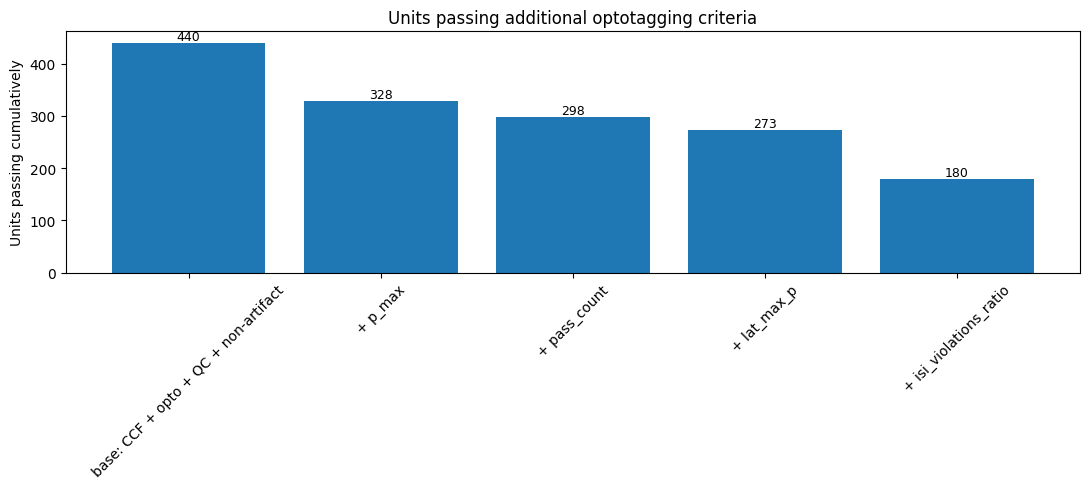

Starting base units: 440
Final passing units: 180


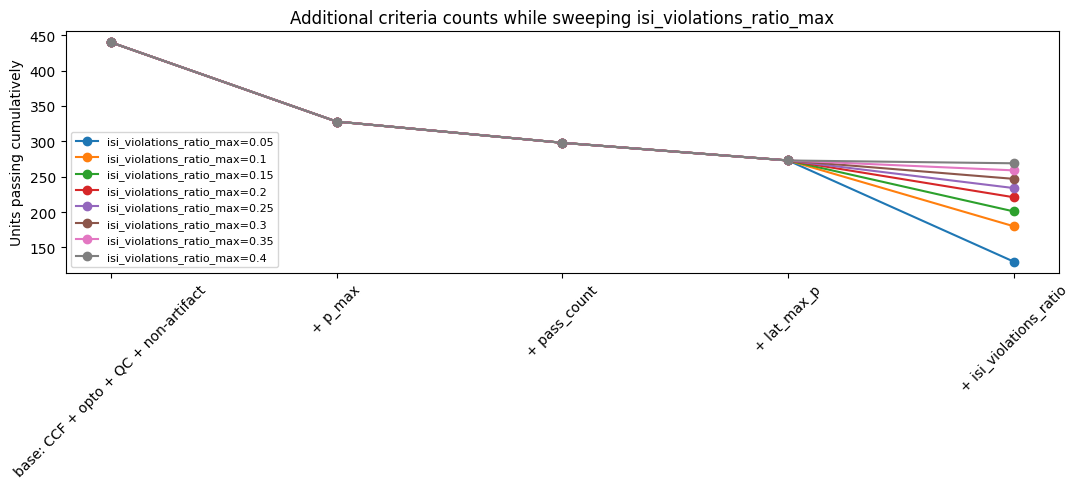

,knob,value,base_n,final_n_pass
0,isi_violations_ratio_max,0.05,440,130
1,isi_violations_ratio_max,0.1,440,180
2,isi_violations_ratio_max,0.15,440,201
3,isi_violations_ratio_max,0.2,440,221
4,isi_violations_ratio_max,0.25,440,234
5,isi_violations_ratio_max,0.3,440,247
6,isi_violations_ratio_max,0.35,440,259
7,isi_violations_ratio_max,0.4,440,269


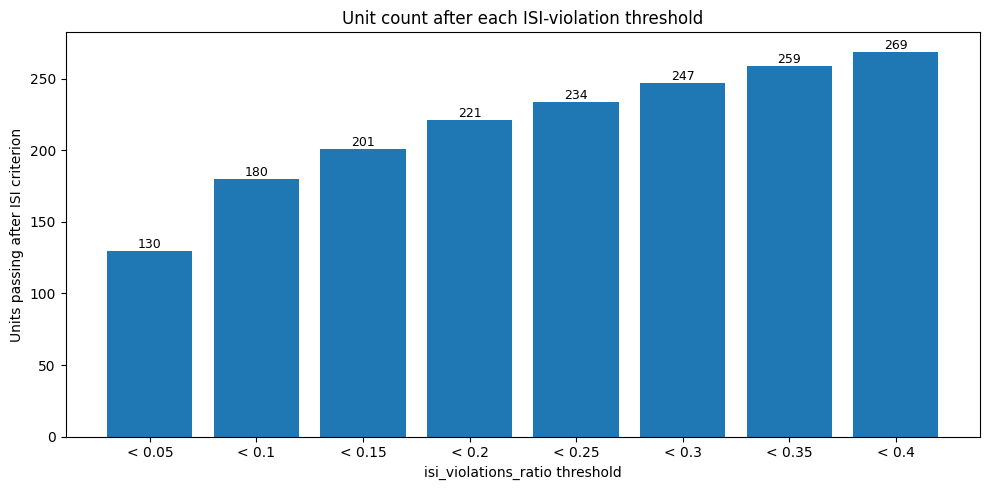

,isi_violations_ratio_max,n_before_isi,n_after_isi,n_removed_by_isi,pct_removed_by_isi
0,0.05,273,130,143,52.380952
1,0.10,273,180,93,34.065934
2,0.15,273,201,72,26.373626
3,0.20,273,221,52,19.047619
4,0.25,273,234,39,14.285714
5,0.30,273,247,26,9.523810
6,0.35,273,259,14,5.128205
7,0.40,273,269,4,1.465201


In [7]:
# %% Chart additional optotagging criteria counts, starting from valid base units

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Knobs to edit for future iterations
# ---------------------------------------------------------------------

# These are automatically included in the starting population:
#   valid CCF + opto_pass + default_qc + non_noise_artifact
#
# The chart starts AFTER those filters.

# Additional criteria are applied in this exact order.
# Reorder, remove, or add criteria here.
CRITERIA_ORDER = [
    "p_max",
    # "p_mean",  # optional; leave commented out if not part of current definition
    "pass_count",
    "lat_max_p",
    "isi_violations_ratio",
]

# Baseline optotagging thresholds.
BASE_CRITERIA = {
    "p_max_min": 0.50,
    "p_mean_min": 0.10,
    "pass_count_min": 2,
    "isi_violations_ratio_max": 0.10,

    # Previous plotting-cell definition:
    #   lat_max_p > 0.005 and lat_max_p < 0.025
    "lat_max_p_range": (0.005, 0.025),
    "lat_max_p_inclusive": False,
}

# Number of comparison values to use when a sweep is generated with np.linspace.
N_SWEEP_STEPS = 8

# Add knobs here to compare alternative threshold values.
# Leave ACTIVE_SWEEPS = [] to make only the baseline successive-criteria chart.
ACTIVE_SWEEPS = [
    #"lat_max_p_range",
    "isi_violations_ratio_max",
    # "p_max_min",
    # "p_mean_min",
    # "pass_count_min",
]

SWEEP_VALUES = {
    "lat_max_p_range": [
        (0.005, 0.020),
        (0.005, 0.025),
        (0.007, 0.025),    
    ],

    "isi_violations_ratio_max": np.linspace(0.05, 0.4, N_SWEEP_STEPS),

    "p_max_min": np.linspace(0.20, 0.70, N_SWEEP_STEPS),
    "p_mean_min": np.linspace(0.02, 0.20, N_SWEEP_STEPS),
    "pass_count_min": [1, 2, 3, 4],
}

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def load_master_path(master_path):
    """
    Load the master unit table from .pkl/.pickle or .csv.
    """
    suffix = Path(master_path).suffix.lower()
    if suffix in [".pkl", ".pickle"]:
        return pd.read_pickle(master_path)
    if suffix == ".csv":
        return pd.read_csv(master_path)
    raise ValueError(f"Unsupported master table extension: {master_path}")


def as_bool_series_local(s):
    """Robust bool conversion for bool/int/string columns."""
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False).astype(bool)

    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float) != 0

    s_str = s.astype(str).str.strip().str.lower()
    return s_str.isin(["true", "1", "1.0", "t", "yes", "y"])


def _format_value_for_label(value):
    if isinstance(value, tuple) and len(value) == 2:
        lo, hi = sorted([float(value[0]), float(value[1])])
        return f"{lo:g}-{hi:g}"
    try:
        value = float(value)
        return f"{value:g}"
    except Exception:
        return str(value)


def _require_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns: {missing}\n"
            f"Available columns include:\n{df.columns.tolist()}"
        )


def make_base_mask(df):
    """
    Starting population:
      valid CCF coordinates
      non-noise/non-artifact decoder label
      opto_pass
      default_qc
    """
    _require_columns(
        df,
        [
            "x_ccf",
            "y_ccf",
            "z_ccf",
            "decoder_label",
            "opto_pass",
            "default_qc",
        ],
    )

    has_ccf = df[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)

    decoder = df["decoder_label"].astype("string").str.strip().str.lower()
    non_noise_artifact = (
        decoder.notna()
        & ~decoder.isin(["noise", "artifact", "nan", "none", "<na>", ""])
    )

    opto_pass_bool = as_bool_series_local(df["opto_pass"])
    default_qc_bool = as_bool_series_local(df["default_qc"])

    return has_ccf & non_noise_artifact & opto_pass_bool & default_qc_bool


def make_criterion_masks(df, cfg, criteria_order):
    """Return one boolean mask per additional named criterion."""
    needed = []

    if "p_max" in criteria_order:
        needed.append("p_max")
    if "p_mean" in criteria_order:
        needed.append("p_mean")
    if "pass_count" in criteria_order:
        needed.append("pass_count")
    if "isi_violations_ratio" in criteria_order:
        needed.append("isi_violations_ratio")
    if "lat_max_p" in criteria_order:
        needed.append("lat_max_p")

    _require_columns(df, needed)

    masks = {}

    if "p_max" in criteria_order:
        p_max = pd.to_numeric(df["p_max"], errors="coerce")
        masks["p_max"] = p_max > float(cfg["p_max_min"])

    if "p_mean" in criteria_order:
        p_mean = pd.to_numeric(df["p_mean"], errors="coerce")
        masks["p_mean"] = p_mean > float(cfg["p_mean_min"])

    if "pass_count" in criteria_order:
        pass_count = pd.to_numeric(df["pass_count"], errors="coerce")
        masks["pass_count"] = pass_count >= float(cfg["pass_count_min"])

    if "isi_violations_ratio" in criteria_order:
        isi_violations_ratio = pd.to_numeric(df["isi_violations_ratio"], errors="coerce")
        masks["isi_violations_ratio"] = isi_violations_ratio < float(cfg["isi_violations_ratio_max"])

    if "lat_max_p" in criteria_order:
        lat_max_p = pd.to_numeric(df["lat_max_p"], errors="coerce")
        lat_lo, lat_hi = sorted([float(x) for x in cfg["lat_max_p_range"]])

        if cfg.get("lat_max_p_inclusive", True):
            masks["lat_max_p"] = lat_max_p.between(lat_lo, lat_hi, inclusive="both")
        else:
            masks["lat_max_p"] = (lat_max_p > lat_lo) & (lat_max_p < lat_hi)

    return masks


def count_successive_criteria(df, cfg, criteria_order):
    """Start from base-valid units, then apply additional criteria one-by-one."""
    cumulative_mask = make_base_mask(df)

    rows = [
        {
            "step": "base: CCF + opto + QC + non-artifact",
            "criterion": "base",
            "n_pass": int(cumulative_mask.sum()),
        }
    ]

    masks = make_criterion_masks(df, cfg, criteria_order)

    for criterion in criteria_order:
        if criterion not in masks:
            raise ValueError(
                f"Unknown criterion {criterion!r}. "
                f"Valid criteria are: {sorted(masks)}"
            )

        before_n = int(cumulative_mask.sum())
        cumulative_mask = cumulative_mask & masks[criterion]
        after_n = int(cumulative_mask.sum())

        rows.append(
            {
                "step": f"+ {criterion}",
                "criterion": criterion,
                "n_pass": after_n,
                "n_removed_at_step": before_n - after_n,
            }
        )

    count_df = pd.DataFrame(rows)
    count_df["n_removed_at_step"] = count_df["n_removed_at_step"].fillna(0).astype(int)

    return count_df, cumulative_mask


def plot_successive_counts(count_df, title):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.bar(count_df["step"], count_df["n_pass"])
    ax.set_ylabel("Units passing cumulatively")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

    for i, n in enumerate(count_df["n_pass"]):
        ax.text(i, n, str(n), ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    plt.show()


def plot_sweep_lines(df, knob, values, base_cfg, criteria_order):
    fig, ax = plt.subplots(figsize=(11, 5))
    summary_rows = []

    for value in values:
        cfg = dict(base_cfg)
        cfg[knob] = value

        count_df, final_mask = count_successive_criteria(df, cfg, criteria_order)
        label = f"{knob}={_format_value_for_label(value)}"

        ax.plot(count_df["step"], count_df["n_pass"], marker="o", label=label)

        summary_rows.append(
            {
                "knob": knob,
                "value": _format_value_for_label(value),
                "base_n": int(count_df.iloc[0]["n_pass"]),
                "final_n_pass": int(final_mask.sum()),
            }
        )

    ax.set_ylabel("Units passing cumulatively")
    ax.set_title(f"Additional criteria counts while sweeping {knob}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)

def count_isi_drop_for_threshold(df, cfg, criteria_order):
    """
    Count units immediately before and after the isi_violations_ratio criterion.
    This respects the current CRITERIA_ORDER, so the ISI drop is measured
    after all criteria that come before isi_violations_ratio.
    """
    if "isi_violations_ratio" not in criteria_order:
        raise ValueError(
            "CRITERIA_ORDER must include 'isi_violations_ratio' to plot ISI drops."
        )

    cumulative_mask = make_base_mask(df)
    masks = make_criterion_masks(df, cfg, criteria_order)

    for criterion in criteria_order:
        if criterion == "isi_violations_ratio":
            n_before_isi = int(cumulative_mask.sum())
            cumulative_mask = cumulative_mask & masks[criterion]
            n_after_isi = int(cumulative_mask.sum())

            return {
                "isi_violations_ratio_max": float(cfg["isi_violations_ratio_max"]),
                "n_before_isi": n_before_isi,
                "n_after_isi": n_after_isi,
                "n_removed_by_isi": n_before_isi - n_after_isi,
                "pct_removed_by_isi": (
                    100.0 * (n_before_isi - n_after_isi) / n_before_isi
                    if n_before_isi > 0
                    else np.nan
                ),
            }

        cumulative_mask = cumulative_mask & masks[criterion]

    raise RuntimeError("Could not compute ISI drop.")


    """
    Bar plot showing how many units are removed by each tested
    isi_violations_ratio threshold.
    """
    rows = []

    for value in values:
        cfg = dict(base_cfg)
        cfg["isi_violations_ratio_max"] = float(value)
        rows.append(count_isi_drop_for_threshold(df, cfg, criteria_order))

    isi_drop_tbl = pd.DataFrame(rows)

    labels = [
        f"< {x:g}"
        for x in isi_drop_tbl["isi_violations_ratio_max"]
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(labels, isi_drop_tbl["n_removed_by_isi"])
    ax.set_xlabel("isi_violations_ratio threshold")
    ax.set_ylabel("Units removed by ISI criterion")
    ax.set_title("Drop in unit count after each ISI-violation threshold")

    for i, row in isi_drop_tbl.iterrows():
        ax.text(
            i,
            row["n_removed_by_isi"],
            f"-{int(row['n_removed_by_isi'])}\n"
            f"{row['n_before_isi']}→{row['n_after_isi']}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.tight_layout()
    plt.show()

    display(isi_drop_tbl)

    return isi_drop_tbl

def plot_isi_iteration_unit_count_bars(df, values, base_cfg, criteria_order):
    """
    Bar plot showing final unit count after applying each tested
    isi_violations_ratio threshold.

    This respects CRITERIA_ORDER, so the count is measured after the ISI
    criterion is applied in the same position as your main chart.
    """
    rows = []

    for value in values:
        cfg = dict(base_cfg)
        cfg["isi_violations_ratio_max"] = float(value)
        rows.append(count_isi_drop_for_threshold(df, cfg, criteria_order))

    isi_count_tbl = pd.DataFrame(rows)

    labels = [
        f"< {x:g}"
        for x in isi_count_tbl["isi_violations_ratio_max"]
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(labels, isi_count_tbl["n_after_isi"])
    ax.set_xlabel("isi_violations_ratio threshold")
    ax.set_ylabel("Units passing after ISI criterion")
    ax.set_title("Unit count after each ISI-violation threshold")

    for i, row in isi_count_tbl.iterrows():
        ax.text(
            i,
            row["n_after_isi"],
            f"{int(row['n_after_isi'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.tight_layout()
    plt.show()

    display(isi_count_tbl)

    return isi_count_tbl
# ---------------------------------------------------------------------
# Run baseline chart
# ---------------------------------------------------------------------

baseline_counts, baseline_mask = count_successive_criteria(
    master,
    BASE_CRITERIA,
    CRITERIA_ORDER,
)

display(baseline_counts)

plot_successive_counts(
    baseline_counts,
    "Units passing additional optotagging criteria",
)

print("Starting base units:", int(baseline_counts.iloc[0]["n_pass"]))
print("Final passing units:", int(baseline_mask.sum()))

# ---------------------------------------------------------------------
# Run comparison sweeps
# ---------------------------------------------------------------------

all_sweep_summaries = []

for knob in ACTIVE_SWEEPS:
    if knob not in SWEEP_VALUES:
        raise ValueError(f"{knob!r} is in ACTIVE_SWEEPS but not defined in SWEEP_VALUES.")

    values = list(SWEEP_VALUES[knob])

    sweep_summary = plot_sweep_lines(
        master,
        knob=knob,
        values=values,
        base_cfg=BASE_CRITERIA,
        criteria_order=CRITERIA_ORDER,
    )

    all_sweep_summaries.append(sweep_summary)

if all_sweep_summaries:
    sweep_summary_tbl = pd.concat(all_sweep_summaries, ignore_index=True)
    display(sweep_summary_tbl)

# ---------------------------------------------------------------------
# Extra ISI-specific unit-count bar plot
# ---------------------------------------------------------------------
MASTER_PATH = "/root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_260710.csv"
master = load_master_path(MASTER_PATH)

if "isi_violations_ratio_max" in ACTIVE_SWEEPS:
    isi_count_tbl = plot_isi_iteration_unit_count_bars(
        master,
        values=SWEEP_VALUES["isi_violations_ratio_max"],
        base_cfg=BASE_CRITERIA,
        criteria_order=CRITERIA_ORDER,
    )

In [15]:
# %% Viable opto-tagged unit counts with adjustable criteria

import os
import numpy as np
import pandas as pd

# -----------------------------
# User knobs
# -----------------------------

MASTER_PATH = "/root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.csv"

# Core criteria
REQUIRE_DEFAULT_QC = True
REQUIRE_OPTO_PASS = True

ISI_VIOLATIONS_RATIO_MAX = 0.1   # set to None to disable
P_MAX_MIN = 0.5                  # set to None to disable

# Latency criteria.
# Most tables store latencies in seconds; this cell accepts ms knobs and auto-converts.
LAT_MEAN_RANGE_MS = (5, 20)      # set to None to disable
LAT_MAX_P_RANGE_MS = None        # e.g. (5, 20), or None to disable

# Waveform similarity / quality criteria
CORR_MAX_P_MIN = 0.85            # e.g. 0.7, or None to disable
EUC_MAX_P_MAX = None             # e.g. 0.4, or None to disable
EUC_MAX_P_MIN = None             # usually None

# CCF coordinate criterion
REQUIRE_VALID_CCF = False        # True = only count units with valid CCF coordinates
CCF_COORD_COLS = ["x_ccf", "y_ccf", "z_ccf"]

# Optional decoder-label cleanup, useful if default_qc is missing or permissive
EXCLUDE_DECODER_LABELS = []      # e.g. ["noise", "artifact"]; leave [] to disable

# Column name preferences / fallbacks
MOUSE_COL_CANDIDATES = ["mouse_id", "subject_id", "subject", "animal_id"]
SESSION_COL_CANDIDATES = ["session_id", "session"]
UNIT_COL_CANDIDATES = ["unit_id", "ks_unit_id"]

# Display options
SHOW_PER_MOUSE_TABLE = True
SHOW_SESSIONS_WITHOUT_CCF = True
SHOW_UNITS_WITHOUT_CCF = False   # can be large


# -----------------------------
# Helpers
# -----------------------------

def first_existing_col(df, candidates, required=True):
    """Return the first column in candidates that exists in df."""
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(
            f"None of these columns were found: {candidates}\n"
            f"Available columns include:\n{list(df.columns)}"
        )
    return None


def as_bool_series(s):
    """Robustly convert booleans stored as bool, 0/1, or strings."""
    if s.dtype == bool:
        return s.fillna(False)

    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float) != 0

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "t": True,
            "1": True,
            "yes": True,
            "y": True,
            "pass": True,
            "passed": True,
            "false": False,
            "f": False,
            "0": False,
            "no": False,
            "n": False,
            "fail": False,
            "failed": False,
            "nan": False,
            "none": False,
            "": False,
        })
        .fillna(False)
    )


def numeric_col(df, col):
    """Return a numeric version of a column."""
    return pd.to_numeric(df[col], errors="coerce")


def latency_bounds_seconds(df, col, ms_range):
    """
    Convert an input ms range to seconds if the table latency appears to be stored in seconds.
    Heuristic: if finite median absolute latency is < 1, assume seconds.
    """
    vals = numeric_col(df, col)
    finite = vals[np.isfinite(vals)]
    if len(finite) == 0:
        return ms_range

    median_abs = np.nanmedian(np.abs(finite))
    if median_abs < 1:
        return tuple(x / 1000 for x in ms_range)
    else:
        # Table probably already in ms
        return ms_range


def valid_ccf_mask(df):
    """
    Valid CCF requires has_ccf True if present, plus non-NaN x/y/z CCF coordinate columns if present.
    """
    mask = pd.Series(True, index=df.index)

    if "has_ccf" in df.columns:
        mask &= as_bool_series(df["has_ccf"])

    existing_coord_cols = [c for c in CCF_COORD_COLS if c in df.columns]
    if existing_coord_cols:
        for col in existing_coord_cols:
            mask &= numeric_col(df, col).notna()
    else:
        print(f"Warning: none of {CCF_COORD_COLS} found; valid CCF is based only on has_ccf, if present.")

    return mask


def add_filter(mask, label, new_condition, rows):
    """Apply one filter and record remaining rows."""
    before = int(mask.sum())
    mask = mask & new_condition.fillna(False)
    after = int(mask.sum())
    rows.append({
        "criterion": label,
        "remaining_units": after,
        "removed_this_step": before - after,
    })
    return mask


# -----------------------------
# Load
# -----------------------------

if not os.path.exists(MASTER_PATH):
    # Helpful fallback for accidental double-dot typo before .csv
    alt_path = MASTER_PATH.replace("..csv", ".csv")
    if os.path.exists(alt_path):
        print(f"MASTER_PATH not found, using fallback:\n{alt_path}")
        MASTER_PATH = alt_path
    else:
        raise FileNotFoundError(f"Could not find:\n{MASTER_PATH}")

df = pd.read_csv(MASTER_PATH)

mouse_col = first_existing_col(df, MOUSE_COL_CANDIDATES)
session_col = first_existing_col(df, SESSION_COL_CANDIDATES)
unit_col = first_existing_col(df, UNIT_COL_CANDIDATES, required=False)

df["_valid_ccf"] = valid_ccf_mask(df)

print(f"Loaded: {MASTER_PATH}")
print(f"Rows: {len(df):,}")
print(f"Mouse column: {mouse_col}")
print(f"Session column: {session_col}")
print(f"Unit column: {unit_col if unit_col else '(using rows as units)'}")


# -----------------------------
# Build filter
# -----------------------------

mask = pd.Series(True, index=df.index)
filter_rows = [{
    "criterion": "All rows",
    "remaining_units": int(mask.sum()),
    "removed_this_step": 0,
}]

if REQUIRE_DEFAULT_QC:
    if "default_qc" not in df.columns:
        raise KeyError("REQUIRE_DEFAULT_QC=True, but column 'default_qc' was not found.")
    mask = add_filter(mask, "default_qc == True", as_bool_series(df["default_qc"]), filter_rows)

if REQUIRE_OPTO_PASS:
    if "opto_pass" not in df.columns:
        raise KeyError("REQUIRE_OPTO_PASS=True, but column 'opto_pass' was not found.")
    mask = add_filter(mask, "opto_pass == True", as_bool_series(df["opto_pass"]), filter_rows)

if EXCLUDE_DECODER_LABELS:
    if "decoder_label" not in df.columns:
        raise KeyError("EXCLUDE_DECODER_LABELS set, but column 'decoder_label' was not found.")
    exclude_lower = {x.lower() for x in EXCLUDE_DECODER_LABELS}
    keep = ~df["decoder_label"].astype(str).str.lower().isin(exclude_lower)
    mask = add_filter(mask, f"decoder_label not in {EXCLUDE_DECODER_LABELS}", keep, filter_rows)

if ISI_VIOLATIONS_RATIO_MAX is not None:
    if "isi_violations_ratio" not in df.columns:
        raise KeyError("ISI_VIOLATIONS_RATIO_MAX set, but column 'isi_violations_ratio' was not found.")
    cond = numeric_col(df, "isi_violations_ratio") < ISI_VIOLATIONS_RATIO_MAX
    mask = add_filter(mask, f"isi_violations_ratio < {ISI_VIOLATIONS_RATIO_MAX}", cond, filter_rows)

if LAT_MEAN_RANGE_MS is not None:
    if "lat_mean" not in df.columns:
        raise KeyError("LAT_MEAN_RANGE_MS set, but column 'lat_mean' was not found.")
    lo, hi = latency_bounds_seconds(df, "lat_mean", LAT_MEAN_RANGE_MS)
    cond = numeric_col(df, "lat_mean").between(lo, hi, inclusive="both")
    mask = add_filter(mask, f"lat_mean between {LAT_MEAN_RANGE_MS[0]}-{LAT_MEAN_RANGE_MS[1]} ms", cond, filter_rows)

if LAT_MAX_P_RANGE_MS is not None:
    if "lat_max_p" not in df.columns:
        raise KeyError("LAT_MAX_P_RANGE_MS set, but column 'lat_max_p' was not found.")
    lo, hi = latency_bounds_seconds(df, "lat_max_p", LAT_MAX_P_RANGE_MS)
    cond = numeric_col(df, "lat_max_p").between(lo, hi, inclusive="both")
    mask = add_filter(mask, f"lat_max_p between {LAT_MAX_P_RANGE_MS[0]}-{LAT_MAX_P_RANGE_MS[1]} ms", cond, filter_rows)

if P_MAX_MIN is not None:
    if "p_max" not in df.columns:
        raise KeyError("P_MAX_MIN set, but column 'p_max' was not found.")
    cond = numeric_col(df, "p_max") > P_MAX_MIN
    mask = add_filter(mask, f"p_max > {P_MAX_MIN}", cond, filter_rows)

if CORR_MAX_P_MIN is not None:
    if "corr_max_p" not in df.columns:
        raise KeyError("CORR_MAX_P_MIN set, but column 'corr_max_p' was not found.")
    cond = numeric_col(df, "corr_max_p") > CORR_MAX_P_MIN
    mask = add_filter(mask, f"corr_max_p > {CORR_MAX_P_MIN}", cond, filter_rows)

if EUC_MAX_P_MIN is not None:
    if "euc_max_p" not in df.columns:
        raise KeyError("EUC_MAX_P_MIN set, but column 'euc_max_p' was not found.")
    cond = numeric_col(df, "euc_max_p") > EUC_MAX_P_MIN
    mask = add_filter(mask, f"euc_max_p > {EUC_MAX_P_MIN}", cond, filter_rows)

if EUC_MAX_P_MAX is not None:
    if "euc_max_p" not in df.columns:
        raise KeyError("EUC_MAX_P_MAX set, but column 'euc_max_p' was not found.")
    cond = numeric_col(df, "euc_max_p") < EUC_MAX_P_MAX
    mask = add_filter(mask, f"euc_max_p < {EUC_MAX_P_MAX}", cond, filter_rows)

if REQUIRE_VALID_CCF:
    mask = add_filter(mask, "valid CCF coordinates", df["_valid_ccf"], filter_rows)


# -----------------------------
# Summaries
# -----------------------------

filtered = df.loc[mask].copy()
filtered_no_ccf = filtered.loc[~filtered["_valid_ccf"]].copy()
filtered_with_ccf = filtered.loc[filtered["_valid_ccf"]].copy()

def nunique_nonnull(x):
    return x.dropna().nunique()

summary = pd.DataFrame({
    "set": [
        "Filtered units",
        "Filtered units with valid CCF",
        "Filtered units without valid CCF",
    ],
    "units": [
        len(filtered),
        len(filtered_with_ccf),
        len(filtered_no_ccf),
    ],
    "unique_sessions": [
        nunique_nonnull(filtered[session_col]),
        nunique_nonnull(filtered_with_ccf[session_col]),
        nunique_nonnull(filtered_no_ccf[session_col]),
    ],
    "unique_mice": [
        nunique_nonnull(filtered[mouse_col]),
        nunique_nonnull(filtered_with_ccf[mouse_col]),
        nunique_nonnull(filtered_no_ccf[mouse_col]),
    ],
})

filter_dropoff = pd.DataFrame(filter_rows)

print("\nFilter drop-off:")
display(filter_dropoff)

print("\nSummary:")
display(summary)

if SHOW_PER_MOUSE_TABLE:
    per_mouse = (
        filtered
        .groupby(mouse_col, dropna=False)
        .agg(
            units=(mouse_col, "size"),
            sessions=(session_col, "nunique"),
            units_with_ccf=("_valid_ccf", "sum"),
            units_without_ccf=("_valid_ccf", lambda x: int((~x).sum())),
        )
        .reset_index()
        .sort_values(["units", mouse_col], ascending=[False, True])
    )

    per_mouse["all_viable_units_missing_ccf"] = per_mouse["units_with_ccf"].eq(0)

    print("\nPer-mouse counts:")
    display(per_mouse)

    mice_with_any_no_ccf = per_mouse.loc[per_mouse["units_without_ccf"] > 0].copy()
    mice_with_all_no_ccf = per_mouse.loc[per_mouse["all_viable_units_missing_ccf"]].copy()

    print("\nMice with at least one filtered unit missing CCF:")
    display(mice_with_any_no_ccf[[mouse_col, "units", "sessions", "units_without_ccf", "units_with_ccf"]])

    print("\nMice whose filtered units are all missing CCF:")
    display(mice_with_all_no_ccf[[mouse_col, "units", "sessions", "units_without_ccf"]])

if SHOW_SESSIONS_WITHOUT_CCF:
    sessions_without_ccf = (
        filtered_no_ccf
        .groupby([mouse_col, session_col], dropna=False)
        .size()
        .reset_index(name="units_without_ccf")
        .sort_values([mouse_col, session_col])
    )

    print("\nSessions containing filtered units without valid CCF:")
    display(sessions_without_ccf)

if SHOW_UNITS_WITHOUT_CCF:
    cols_to_show = [
        c for c in [
            mouse_col, session_col, unit_col,
            "default_qc", "opto_pass",
            "isi_violations_ratio", "lat_mean", "lat_max_p",
            "p_max", "corr_max_p", "euc_max_p",
            "has_ccf", "x_ccf", "y_ccf", "z_ccf",
        ]
        if c is not None and c in filtered_no_ccf.columns
    ]

    print("\nFiltered units without valid CCF:")
    display(filtered_no_ccf[cols_to_show].sort_values([mouse_col, session_col]))

Loaded: /root/capsule/scratch/combined/master_unit_tables/master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.csv
Rows: 15,184
Mouse column: mouse_id
Session column: session_id
Unit column: unit_id

Filter drop-off:


,criterion,remaining_units,removed_this_step
0,All rows,15184,0
1,default_qc == True,6482,8702
2,opto_pass == True,807,5675
3,isi_violations_ratio < 0.1,465,342
4,lat_mean between 5-20 ms,435,30
5,p_max > 0.5,272,163
6,corr_max_p > 0.85,223,49



Summary:


,set,units,unique_sessions,unique_mice
0,Filtered units,223,45,16
1,Filtered units with valid CCF,165,35,12
2,Filtered units without valid CCF,58,10,4



Per-mouse counts:


...

,mouse_id,units,sessions,units_without_ccf,units_with_ccf
13,844917,38,3,38,0
15,848869,13,3,13,0
14,844920,5,2,5,0
9,841599,2,2,2,0



Mice whose filtered units are all missing CCF:


,mouse_id,units,sessions,units_without_ccf
13,844917,38,3,38
15,848869,13,3,13
14,844920,5,2,5
9,841599,2,2,2



Sessions containing filtered units without valid CCF:


,mouse_id,session_id,units_without_ccf
0,841599,behavior_841599_2026-05-13_13-19-27,1
1,841599,behavior_841599_2026-05-14_13-27-52,1
2,844917,behavior_844917_2026-06-02_11-08-15,1
3,844917,behavior_844917_2026-06-03_12-56-55,3
4,844917,behavior_844917_2026-06-04_12-30-01,34
5,844920,behavior_844920_2026-06-10_11-30-14,4
6,844920,behavior_844920_2026-06-12_11-03-09,1
7,848869,behavior_848869_2026-05-12_08-51-54,10
8,848869,behavior_848869_2026-05-14_08-45-55,1
9,848869,behavior_848869_2026-05-15_08-59-55,2


# Plot combined opto units

In [6]:
# plot all session with p_response in space
txt_file = "/root/capsule/code/data_management/animal_ids.txt"

with open(txt_file) as f:
    animal_ids = [line.strip() for line in f if line.strip()]

all_brains = animal_ids
# all_brains = ['751766', '752014', '754897', '758017', '758018', '761038', '782394', '784803', '784806', '785956', '791691', '763590', '781166', '']
all_sessions = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')['session_id'].to_list()
all_sessions = [
    session for session in all_sessions 
    if isinstance(session, str) and any(brain in session for brain in all_brains)
]


In [7]:
txt_file = "/root/capsule/code/data_management/animal_ids.txt"

with open(txt_file) as f:
    animal_ids = [line.strip() for line in f if line.strip()]

In [21]:
all_ccfs_tbls = []
for session in all_sessions:
    unit_tbl = get_unit_tbl(session, data_type='curated')
    if unit_tbl is not None:
        corr = unit_tbl['corr_max_p'].values
        corr[np.isnan(corr)] = 1
        unit_tbl_filtered = unit_tbl[(unit_tbl['decoder_label']!='noise') & (unit_tbl['decoder_label']!='artifact') & (corr>0.85)]
        all_ccfs_tbls.append(unit_tbl_filtered)
all_ccfs_tbl = pd.concat(all_ccfs_tbls, ignore_index=True)


No unit table found for behavior_751766_2025-02-15_12-08-11 in curated data.


/tmp/ipykernel_2565403/2976536407.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_ccfs_tbl = pd.concat(all_ccfs_tbls, ignore_index=True)


In [4]:

# --- Load and preprocess mesh ---
norm = Normalize(vmin=0, vmax=1)
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}

mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
mesh = load_mesh(mesh_file)
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

# add the other side
mesh_vertices_mm_flipped = mesh_vertices_mm.copy()
mesh_vertices_mm_flipped[:, ml] = -mesh_vertices_mm_flipped[:, ml]


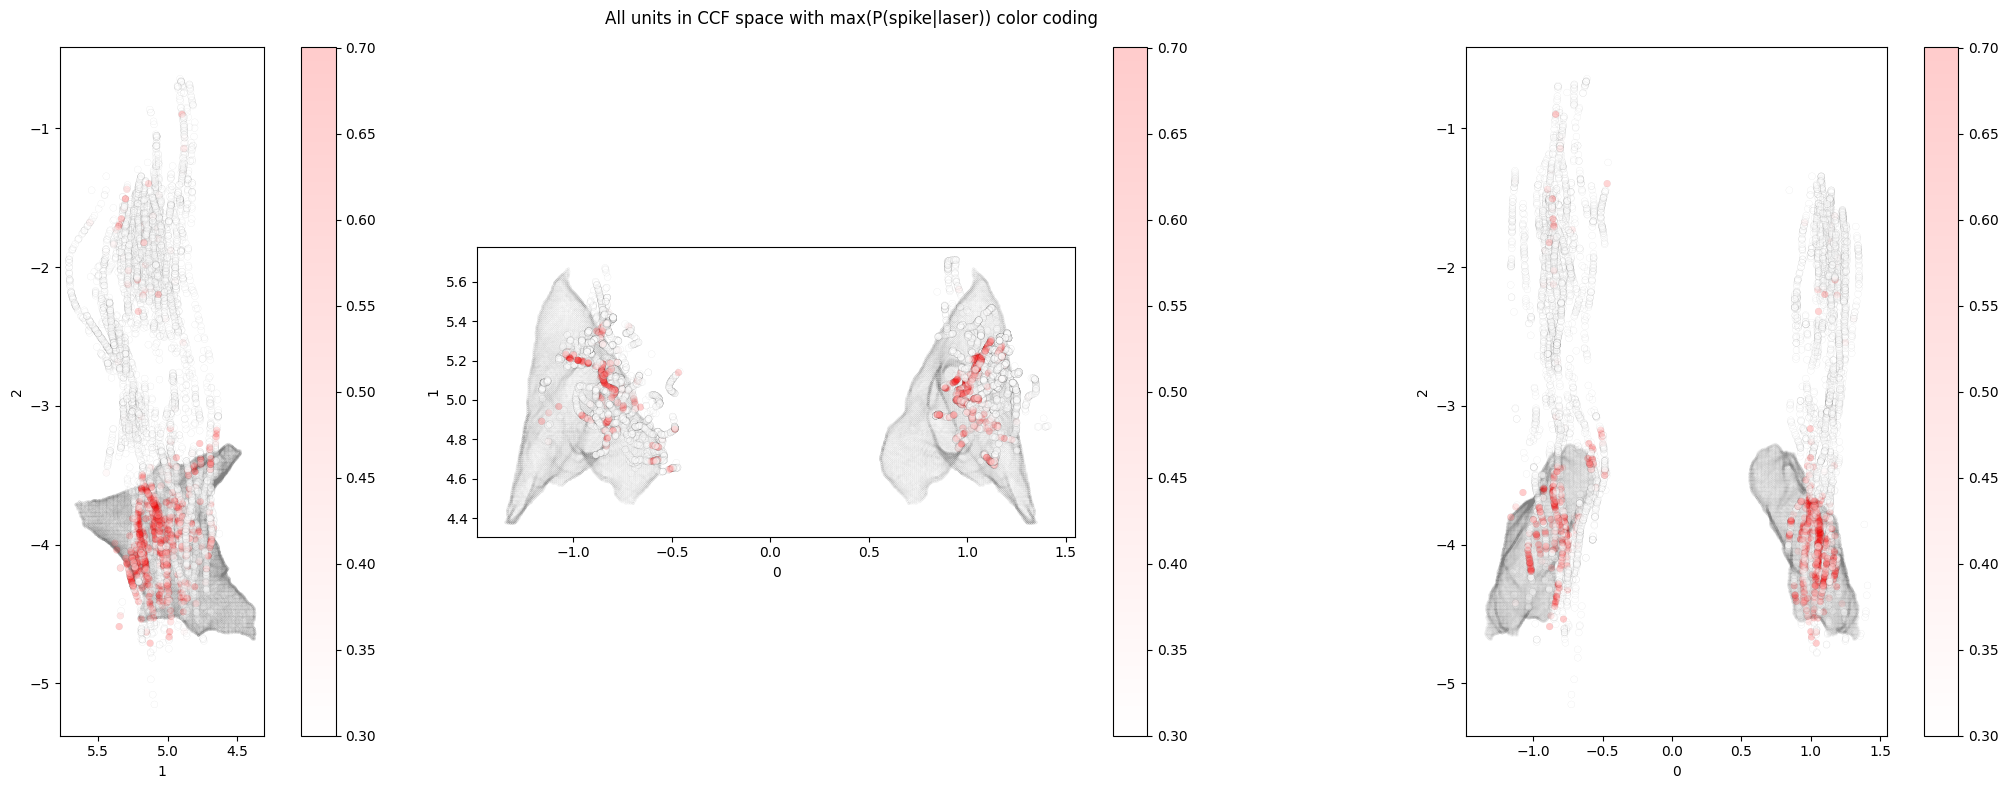

In [25]:
# Plot the points
ccfs = all_ccfs_tbl[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
# ccfs[ccfs[:, ml]>0, ml] = -ccfs[ccfs[:, ml]>0, ml]
ccf_units = ccfs.copy()
# mesh_vertices_mm = np.vstack([mesh_vertices_mm, mesh_vertices_mm_flipped])
from matplotlib.colors import LinearSegmentedColormap

white_to_red = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["white", "red"]
)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
import matplotlib.cm as cm
import matplotlib.patches as mpatches
for plane, ax in zip(planes.keys(), axes):
    # Plot the mesh
    ax.scatter(
        mesh_vertices_mm[:, planes[plane][0]],
        mesh_vertices_mm[:, planes[plane][1]],
        color='gray', alpha=0.5, s=0.001,
        edgecolors=None
    )

    ax.scatter(
        mesh_vertices_mm_flipped[:, planes[plane][0]],
        mesh_vertices_mm_flipped[:, planes[plane][1]],
        color='gray', alpha=0.5, s=0.001,
        edgecolors=None
    )

    norm = Normalize(vmin=0.3, vmax=0.7, clip=True)

    sc = ax.scatter(
        ccfs[:, planes[plane][0]],
        ccfs[:, planes[plane][1]],
        c=all_ccfs_tbl['p_max'],
        cmap=white_to_red,
        norm=norm,
        s=25,
        alpha=0.2,
        edgecolors='k',
        linewidths=0.1,
    )

    # add colorbar
    cbar = plt.colorbar(sc, ax=ax)
    # sort_ind = np.argsort(ccfs[:, dv])
    
    # ax.plot(ccfs[sort_ind, planes[plane][0]], ccfs[sort_ind, planes[plane][1]], color=cm.get_cmap(colormaps[session_ind])(1.0), label=session, linewidth=0.5)

    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    ax.set_aspect('equal')

# add the legend with brightest color for each session


# axes[0].invert_yaxis()
axes[0].invert_xaxis()
# axes[2].invert_yaxis()


plt.suptitle(f'All units in CCF space with max(P(spike|laser)) color coding')
plt.tight_layout()
plt.savefig(f'/root/capsule/scratch/combined/ccf_maps/all_units_ccf_opto_tag.png', dpi=300)
plt.show()


In [5]:
import numpy as np
import k3d
from matplotlib.colors import Normalize

# ----------------------------
# Prepare data (same as yours)
# ----------------------------
ccfs = all_ccfs_tbl[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
ccfs = ccfs - bregma_LPS_mm
ccf_units = ccfs.copy()

p_max = all_ccfs_tbl['p_max'].values

# ----------------------------
# Color normalization: 0.3 -> white, 0.7 -> red
# ----------------------------
norm = Normalize(vmin=0.3, vmax=0.7, clip=True)
p_norm = norm(p_max)

# k3d expects uint32 colors (0xRRGGBB)
def white_to_red_rgb(v):
    r = 255
    g = int(255 * (1 - v))
    b = int(255 * (1 - v))
    return (r << 16) + (g << 8) + b

colors = np.array([white_to_red_rgb(v) for v in p_norm], dtype=np.uint32)

# ----------------------------
# Create k3d plot
# ----------------------------
plot = k3d.plot(
    camera_auto_fit=True,
    axes=['ML', 'DV', 'AP'],
    grid_visible=True,
)

# ----------------------------
# Plot mesh (both hemispheres)
# ----------------------------
plot += k3d.points(
    positions=mesh_vertices_mm.astype(np.float32),
    color=0x888888,
    point_size=0.02,
    opacity=0.15,
)

plot += k3d.points(
    positions=mesh_vertices_mm_flipped.astype(np.float32),
    color=0x888888,
    point_size=0.02,
    opacity=0.15,
)

# ----------------------------
# Plot units
# ----------------------------
plot += k3d.points(
    positions=ccf_units.astype(np.float32),
    colors=colors,
    point_size=0.05,
    opacity=0.3,
)

# ----------------------------
# Show
# ----------------------------
plot


NameError: name 'all_ccfs_tbl' is not defined

# Plot dorsal edge

In [8]:
txt_file = "/root/capsule/code/data_management/animal_ids.txt"

with open(txt_file) as f:
    animal_ids = [line.strip() for line in f if line.strip()]
concat_dorsal_edge = []
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
for animal_id in animal_ids:
    dorsal_edge_json = f'/root/capsule/data/dorsal_edges/{animal_id}_dorsal_edge_ccf_fix.json'
    if os.path.exists(dorsal_edge_json):
        with open(dorsal_edge_json, 'r') as f:
            dorsal_edge_dict = json.load(f)
        # make into a dataframe
        dorsal_edge_df = pd.DataFrame(dorsal_edge_dict['xyz_picks'], columns=['x', 'y', 'z'])
        # make into a dataframe
        # dorsal_edge_df['x'] = -dorsal_edge_df['x']
        # dorsal_edge_df['y'] = -dorsal_edge_df['y']
        # dorsal_edge_df['z'] = dorsal_edge_df['z']
        dorsal_edge_mat = dorsal_edge_df.values
        # dorsal_edge_mat[:, 0] = dorsal_edge_mat[:, 0] - 0.04
        dorsal_edge_mat[:, ml]  = np.abs(dorsal_edge_mat[:, ml])
        concat_dorsal_edge.append(dorsal_edge_mat)
ccfs = np.vstack(concat_dorsal_edge)
# --- Load and preprocess mesh ---
norm = Normalize(vmin=0, vmax=1)
mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
mesh = load_mesh(mesh_file)
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}
# add the other side
# mesh_vertices_mm_flipped = mesh_vertices_lps.copy()
# mesh_vertices_mm_flipped[:, ml] = -mesh_vertices_mm_flipped[:, ml]

mesh_file = '/root/capsule/scratch/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj' 
mesh = load_mesh(mesh_file)
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # mm
mesh_vertices = np.array(mesh.vertices)

if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm_old = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm_old[:, ml] = np.abs(mesh_vertices_mm_old[:, ml])

mesh_contours_old = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}
# add the other side
# mesh_vertices_mm_flipped = mesh_vertices_lps.copy()
# mesh_vertices_mm_flipped[:, ml] = -mesh_vertices_mm_flipped[:, ml]

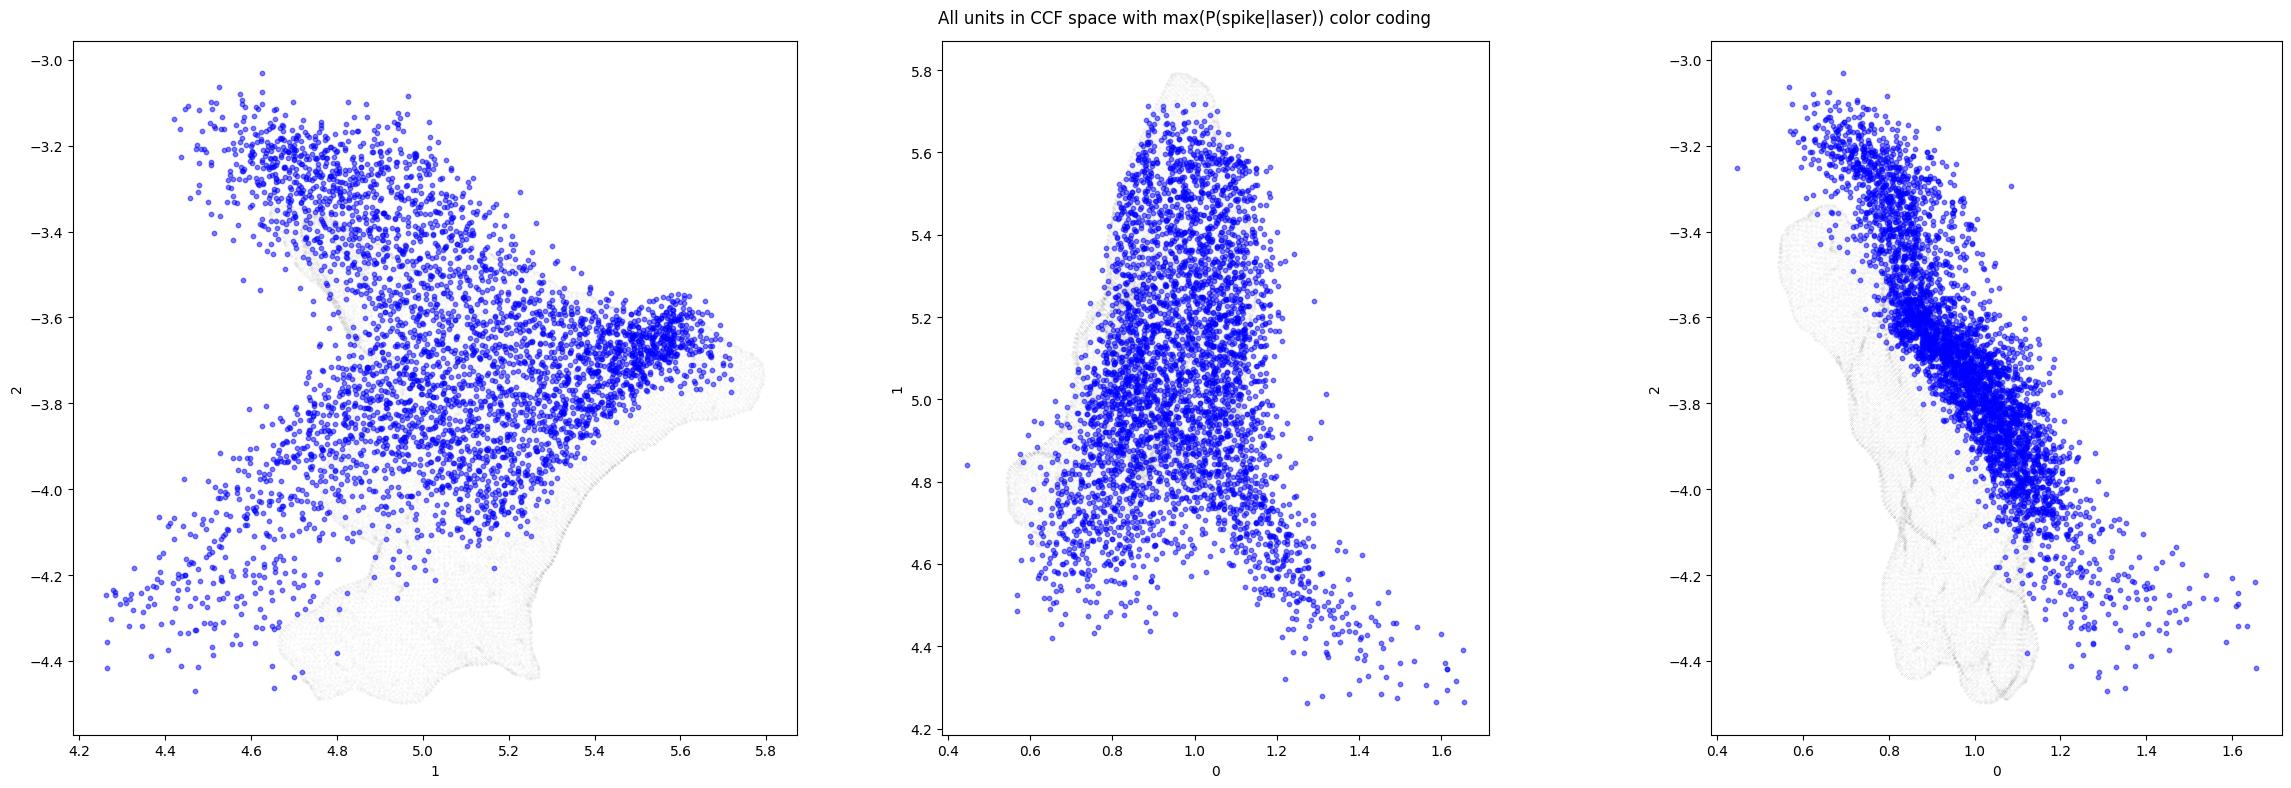

In [29]:
# Plot the points

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
import matplotlib.cm as cm
import matplotlib.patches as mpatches
for plane, ax in zip(planes.keys(), axes):
    # Plot the mesh
    ax.scatter(
        mesh_vertices_mm[:, planes[plane][0]],
        mesh_vertices_mm[:, planes[plane][1]],
        color='gray', alpha=0.5, s=0.005,
        edgecolors=None
    )

    sc = ax.scatter(
        ccfs[:, planes[plane][0]],
        ccfs[:, planes[plane][1]],
        color='b',
        s=10, alpha=0.5,
        edgecolors=None, linewidths=1,
    )

    # sc = ax.scatter(
    #     ccf_units[:, planes[plane][0]],
    #     ccf_units[:, planes[plane][1]],
    #     c=all_ccfs_tbl['p_max'],
    #     cmap='Reds',
    #     norm=Normalize(vmin=0, vmax=0.6),
    #     s=35, alpha=0.3,
    #     edgecolors=None, linewidths=1,
    # )
    
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    ax.set_aspect('equal')

# add the legend with brightest color for each session


# axes[0].invert_yaxis()
# axes[0].invert_xaxis()
# axes[2].invert_yaxis()


plt.suptitle(f'All units in CCF space with max(P(spike|laser)) color coding')
plt.tight_layout()
# plt.savefig(f'/root/capsule/scratch/combined/ccf_maps/dorsal_edge_LC.png', dpi=300)
plt.show()


In [12]:

import matplotlib.cm as cm

# 3D plot of list of mesh vertices
plot = k3d.plot()
mesh_list = os.listdir('/root/capsule/data/LC_percentile_meshes')
mesh_list = [f for f in mesh_list if f.endswith('.obj')]
percentile = [name.split('.')[0].split('_')[-1] for name in mesh_list]
# if number convert to number, if not set to none
def to_float_or_none(x):
    try:
        return float(x)
    except ValueError:
        return None
percentile = [to_float_or_none(p) for p in percentile]

cmap = cm.get_cmap('viridis')
n_mesh = len(mesh_list)

for i, mesh_file in enumerate(mesh_list):

    mesh_file_curr = os.path.join('/root/capsule/data/LC_percentile_meshes', mesh_file)
    mesh_vertices = load_mesh(mesh_file_curr).vertices

    mesh_vertices = mesh_vertices / 1000
    mesh_vertices[:, 2] = -mesh_vertices[:, 2]
    mesh_vertices[:, 0] = -mesh_vertices[:, 0]

    mesh_vertices = mesh_vertices - bregma_LPS_mm
    mesh_vertices[:, ml] = np.abs(mesh_vertices[:, ml])

    # get color for this mesh
    if percentile[i] is not None:
        rgba = cmap(percentile[i] / 100)
        rgb = (np.array(rgba[:3]) * 255).astype(np.uint32)
    else:
        rgb = np.array([128, 128, 128], dtype=np.uint32)

    color_hex = (rgb[0] << 16) + (rgb[1] << 8) + rgb[2]

    colors = np.full(mesh_vertices.shape[0], color_hex, dtype=np.uint32)

    plot += k3d.points(
        positions=mesh_vertices.astype(np.float32),
        colors=colors,
        point_size=0.01,
        opacity=0.1,
        name=mesh_file.split('.')[0]
    )

# mesh_vertices_mm_old
plot += k3d.points(
    positions=mesh_vertices_mm_old.astype(np.float32),
    color=0x000000,  # black color
    point_size=0.01,
    opacity=0.1,
    name='old CCF Mesh'
    
)

plot += k3d.points(
    positions=ccfs.astype(np.float32),
    point_size=0.01,
    # shader='3d'
)

# Add unit points, colored by p_max
# plot += k3d.points(
#     positions=ccf_units.astype(np.float32),
#     colors=colors,
#     point_size=0.03,
#     shader='3d'
# )

# save as html
html_file = f'/root/capsule/scratch/combined/ccf_maps/dorsal_edge_ccf_plot.html'
with open(html_file, 'w') as f:
    f.write(plot.get_snapshot())
# --- Display ---
plot.display()

/tmp/ipykernel_734481/504784423.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


Output()

In [31]:
import numpy as np
import k3d
from matplotlib import cm
from matplotlib.colors import Normalize

# --- Normalize colormap based on p_max ---

# --- Load and convert mesh ---
# ml, ap, dv = 2, 0, 1
# mesh = load_mesh('/root/capsule/scratch/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj')
# mesh_vertices = np.array(mesh.vertices)
# mesh_vertices_mm = ccf_pts_convert_to_mm(mesh_vertices)

# # Add mirrored hemisphere
# mesh_vertices_mm_flipped = mesh_vertices_mm.copy()
# mesh_vertices_mm_flipped[:, ml] = -mesh_vertices_mm_flipped[:, ml]
# mesh_vertices_mm = np.vstack([mesh_vertices_mm, mesh_vertices_mm_flipped])

# #--- Prepare unit coordinates ---
# x_ccf = -all_ccfs_tbl['x_ccf'].values / 25 * 1000
# y_ccf = all_ccfs_tbl['y_ccf'].values / 25 * 1000
# z_ccf = -all_ccfs_tbl['z_ccf'].values / 25 * 1000
# ccfs = np.column_stack((y_ccf, z_ccf, x_ccf))
# ccfs = ccf_pts_convert_to_mm(ccfs)
# ccfs[ccfs[:, ml] > 0, ml] = -ccfs[ccfs[:, ml] > 0, ml]



# --- Create k3d plot ---
plot = k3d.plot(background_color=0xffffff, grid_visible=False, axes_helper=0)

# Add semi-transparent mesh (gray)
plot += k3d.points(
    positions=mesh_vertices_mm.astype(np.float32),
    colors=np.full(mesh_vertices_mm.shape[0], 0x808080, dtype=np.uint32),
    point_size=0.01,
    opacity=0.15
)

plot += k3d.points(
    positions=mesh_vertices_mm_old.astype(np.float32),
    colors=np.full(mesh_vertices_mm_old.shape[0], 0x4DA6FF, dtype=np.uint32),
    point_size=0.01,
    opacity=0.15
)



# # add the other side
# plot += k3d.points(
#     positions=mesh_vertices_mm_flipped.astype(np.float32),
#     colors=np.full(mesh_vertices_mm_flipped.shape[0], 0x808080, dtype=np.uint32),
#     point_size=0.02,
#     opacity=0.15
# )

# Add dorsal edge (blue)
plot += k3d.points(
    positions=ccfs.astype(np.float32),
    point_size=0.01,
    # shader='3d'
)

# Add unit points, colored by p_max
# plot += k3d.points(
#     positions=ccf_units.astype(np.float32),
#     colors=colors,
#     point_size=0.03,
#     shader='3d'
# )

# save as html
html_file = f'/root/capsule/scratch/combined/ccf_maps/dorsal_edge_ccf_plot.html'
with open(html_file, 'w') as f:
    f.write(plot.get_snapshot())
# --- Display ---
plot.display()


Output()